In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!pip install -q segmentation-models-pytorch
!pip install -q pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.2 MB/s eta 0:00:0000:01


In [2]:
import os
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 361.2/361.2 kB 5.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 68.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.0 MB/s eta 0:00:00


In [4]:
from kaggle_secrets import UserSecretsClient
from roboflow import Roboflow

WORKSPACE = "august-4t80o"
PROJECT = "solar-dust"
VERSION = 1
FORMAT = "coco"

api_key = UserSecretsClient().get_secret("roboflow_api_key")

rf = Roboflow(api_key=api_key)

project = rf.workspace(WORKSPACE).project(PROJECT)

dataset = project.version(VERSION).download(
    FORMAT,
    location="/kaggle/working/dataset"
)

print("Dataset downloaded successfully!")
print("Dataset location:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /kaggle/working/dataset in coco:: 100%|██████████| 6760/6760 [00:01<00:00, 5993.45it/s]


Dataset downloaded successfully!
Dataset location: /kaggle/working/dataset


In [5]:
DATASET_DIR = Path("/kaggle/working/dataset")

for path in DATASET_DIR.rglob("*"):
    print(path)

/kaggle/working/dataset/valid
/kaggle/working/dataset/README.roboflow.txt
/kaggle/working/dataset/train
/kaggle/working/dataset/README.dataset.txt
/kaggle/working/dataset/test
/kaggle/working/dataset/valid/IMG_8585_jpg.rf.3004832309e0f054d5aaf28ac26f1280.jpg
/kaggle/working/dataset/valid/IMG_0396_jpg.rf.0f45afc981a06beb84a34f6d2bb9c2ee.jpg
/kaggle/working/dataset/valid/Imgclean_264_0_jpg.rf.4bf1e9cdb88fa590cc11da3952588d1f.jpg
/kaggle/working/dataset/valid/Imgclean_987_0_jpg.rf.9cff9f2caa93816562143ed09af18e18.jpg
/kaggle/working/dataset/valid/Bird-61-_jpg.rf.86b7a172d9a78cffda3d4fde0634547c.jpg
/kaggle/working/dataset/valid/Clean-189-_jpg.rf.86e6664711c347c9b248054bf3fe808d.jpg
/kaggle/working/dataset/valid/cracked-ff3c284a-fe6f-11ed-9a94-5c60ba7633ae_jpg.rf.9b90bdfbe90ed5a259992169d4ad15f6.jpg
/kaggle/working/dataset/valid/Imgclean_1060_0_jpg.rf.53c0926cb2a8844bca6fad78789dc1cf.jpg
/kaggle/working/dataset/valid/poop-61-_jpg.rf.012718a6466a06555ccccfd4663e9845.jpg
/kaggle/working/data

In [6]:
import json

json_files = list(DATASET_DIR.rglob("*.json"))

print("JSON files found:", len(json_files))

for f in json_files:
    print(f)

JSON files found: 3
/kaggle/working/dataset/valid/_annotations.coco.json
/kaggle/working/dataset/train/_annotations.coco.json
/kaggle/working/dataset/test/_annotations.coco.json


In [7]:
with open(json_files[0], "r") as f:
    coco = json.load(f)

print("Images:", len(coco["images"]))
print("Annotations:", len(coco["annotations"]))
print("Categories:", len(coco["categories"]))

for category in coco["categories"]:
    print(category)

Images: 524
Annotations: 924
Categories: 4
{'id': 0, 'name': 'bird-dust-clean-aUfv', 'supercategory': 'none'}
{'id': 1, 'name': 'bird_drop', 'supercategory': 'bird-dust-clean-aUfv'}
{'id': 2, 'name': 'clean', 'supercategory': 'bird-dust-clean-aUfv'}
{'id': 3, 'name': 'dust', 'supercategory': 'bird-dust-clean-aUfv'}


In [8]:
from collections import Counter

category_counts = Counter(
    ann["category_id"]
    for ann in coco["annotations"]
)

print("Annotation distribution:")

for category in coco["categories"]:
    cid = category["id"]
    name = category["name"]

    print(
        f"{cid} - {name}: "
        f"{category_counts.get(cid, 0)}"
    )

Annotation distribution:
0 - bird-dust-clean-aUfv: 0
1 - bird_drop: 438
2 - clean: 257
3 - dust: 229


In [9]:
image_info = []

for img in coco["images"]:
    image_info.append({
        "id": img["id"],
        "file_name": img["file_name"],
        "width": img["width"],
        "height": img["height"]
    })

df_images = pd.DataFrame(image_info)

print(df_images.head())
print("\nDimension distribution:")
print(df_images[["width", "height"]].value_counts())

   id                                          file_name  width  height
0   0  Dust-163-_jpg.rf.517fa8edef86b7bb97d9a5b16c84f...    640     640
1   1  poop-206-_jpg.rf.fe6d8f5057802223f84a98ce5095e...    640     640
2   2  photo_2023-07-19_16-27-52-2-_jpg.rf.8e7d26f273...    640     640
3   3  photo_2023-07-19_16-27-53-2-_jpg.rf.72774e82e7...    640     640
4   4  poop-206-_jpg.rf.dfd81707e1e835c35e4eb63fb9a19...    640     640

Dimension distribution:
width  height
640    640       524
Name: count, dtype: int64


In [10]:
from pycocotools import mask as mask_utils

# Create image lookup
image_lookup = {
    img["id"]: img
    for img in coco["images"]
}

# Group annotations by image
annotations_by_image = {}

for ann in coco["annotations"]:
    image_id = ann["image_id"]

    if image_id not in annotations_by_image:
        annotations_by_image[image_id] = []

    annotations_by_image[image_id].append(ann)


def polygon_to_mask(image_info, annotations):

    height = image_info["height"]
    width = image_info["width"]

    final_mask = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    for ann in annotations:

        segmentation = ann["segmentation"]

        if not segmentation:
            continue

        # Handle COCO RLE format
        if isinstance(segmentation, dict):

            rle = segmentation

            # If counts is a string, convert it to bytes
            if isinstance(rle["counts"], str):
                rle["counts"] = rle["counts"].encode("utf-8")

            mask = mask_utils.decode(rle)

        # Handle COCO polygon format
        else:

            rles = mask_utils.frPyObjects(
                segmentation,
                height,
                width
            )

            rle = mask_utils.merge(rles)

            mask = mask_utils.decode(rle)

        # Convert to binary mask
        if len(mask.shape) == 3:
            mask = np.any(mask, axis=2)

        final_mask = np.maximum(
            final_mask,
            mask.astype(np.uint8)
        )

    return final_mask


print("Annotation grouping completed.")
print("Total images:", len(image_lookup))
print("Images with annotations:", len(annotations_by_image))

Annotation grouping completed.
Total images: 524
Images with annotations: 523


In [11]:
# Take the first annotated image
image_id = next(iter(annotations_by_image))

image_info = image_lookup[image_id]
annotations = annotations_by_image[image_id]

# Generate mask
final_mask = polygon_to_mask(
    image_info,
    annotations
)

# Check mask
unique_values = np.unique(final_mask)

print("Image:", image_info["file_name"])
print("Mask shape:", final_mask.shape)
print("Mask pixel values:", unique_values)

Image: Dust-163-_jpg.rf.517fa8edef86b7bb97d9a5b16c84f6e1.jpg
Mask shape: (640, 640)
Mask pixel values: [0 1]


In [12]:
background_pixels = 0
dust_pixels = 0

for image_id, annotations in annotations_by_image.items():

    image_info = image_lookup[image_id]

    mask = polygon_to_mask(
        image_info,
        annotations
    )

    background_pixels += np.sum(mask == 0)
    dust_pixels += np.sum(mask == 1)

total_pixels = background_pixels + dust_pixels

print("Background pixels:", background_pixels)
print("Dust pixels:", dust_pixels)

print(f"Background: {background_pixels / total_pixels * 100:.2f}%")
print(f"Dust:       {dust_pixels / total_pixels * 100:.2f}%")

Background pixels: 128686278
Dust pixels: 85534522
Background: 60.07%
Dust:       39.93%


Image found at:
/kaggle/working/dataset/valid/Dust-163-_jpg.rf.517fa8edef86b7bb97d9a5b16c84f6e1.jpg
Image size : (640, 640)
Mask size  : (640, 640)
Mask values: [0 1]


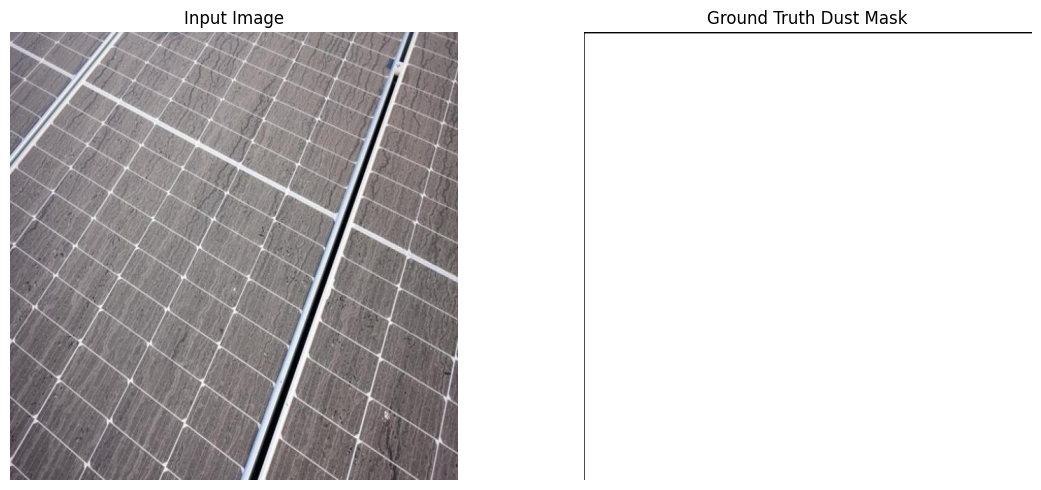

In [13]:
# CELL 12 — Image and Ground Truth Mask Validation

image_id = next(iter(annotations_by_image))

image_info = image_lookup[image_id]
annotations = annotations_by_image[image_id]

file_name = image_info["file_name"]

# Find the actual image inside train/valid/test folders
matches = list(DATASET_DIR.rglob(Path(file_name).name))

if len(matches) == 0:
    raise FileNotFoundError(f"Image not found: {file_name}")

image_path = matches[0]

print("Image found at:")
print(image_path)

# Load image
image = Image.open(image_path).convert("RGB")

# Generate ground-truth mask
mask = polygon_to_mask(image_info, annotations)

print("Image size :", image.size)
print("Mask size  :", mask.shape)
print("Mask values:", np.unique(mask))

# Display
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Dust Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

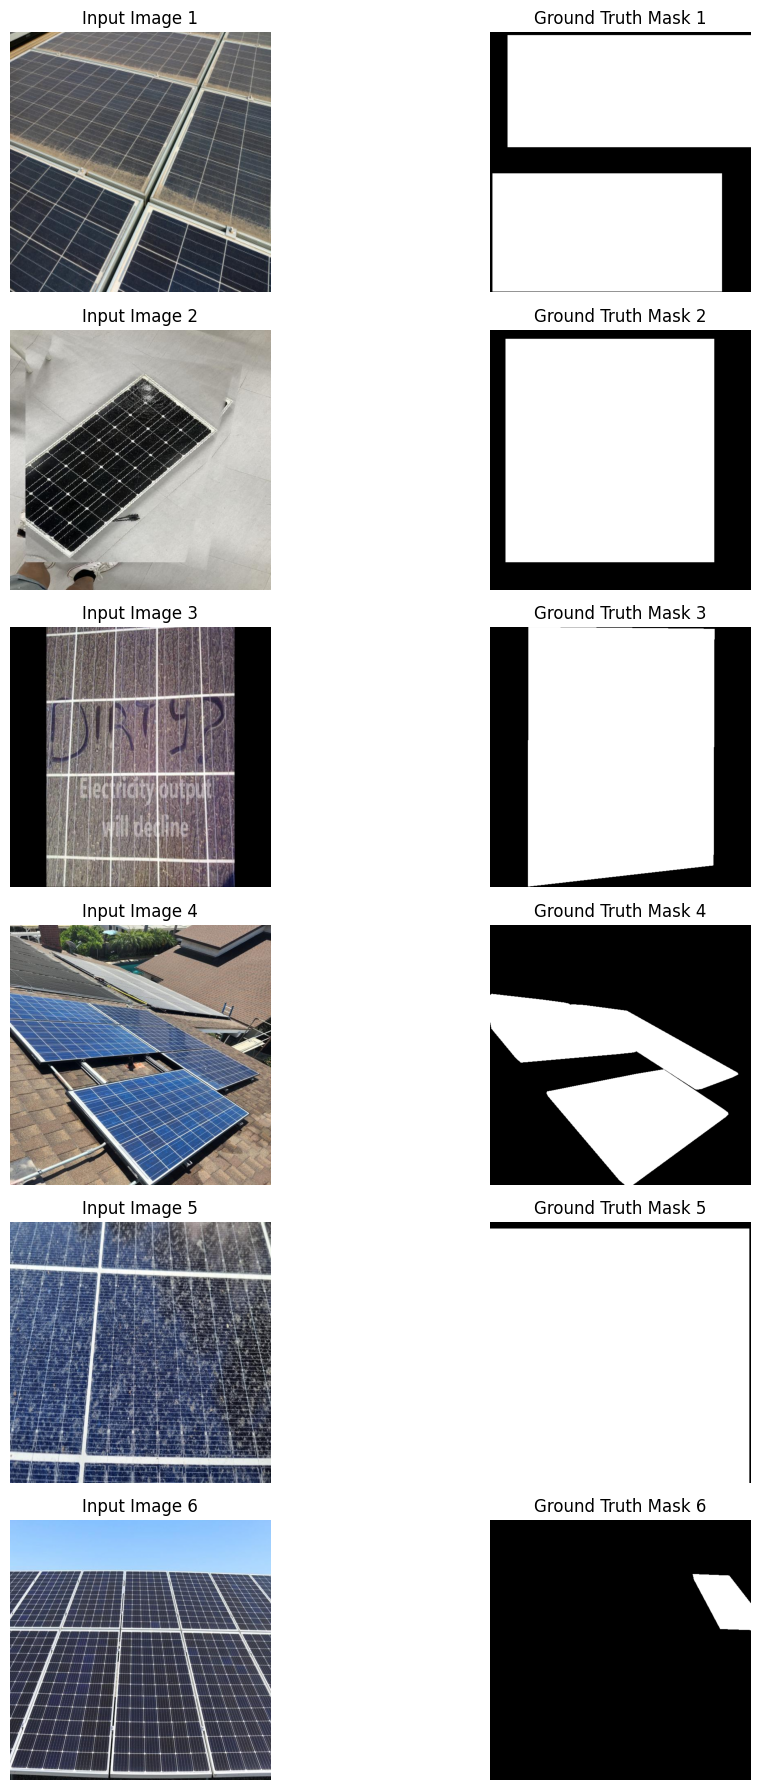

In [14]:
# CELL 13 — Multiple sample validation

import random

sample_image_ids = random.sample(
    list(annotations_by_image.keys()),
    min(6, len(annotations_by_image))
)

plt.figure(figsize=(12, 18))

for i, image_id in enumerate(sample_image_ids):

    image_info = image_lookup[image_id]
    annotations = annotations_by_image[image_id]

    # Find image
    matches = list(DATASET_DIR.rglob(Path(image_info["file_name"]).name))

    if not matches:
        print("Image not found:", image_info["file_name"])
        continue

    image_path = matches[0]

    # Load image and mask
    image = Image.open(image_path).convert("RGB")
    mask = polygon_to_mask(image_info, annotations)

    # Input image
    plt.subplot(6, 2, 2*i + 1)
    plt.imshow(image)
    plt.title(f"Input Image {i+1}")
    plt.axis("off")

    # Ground truth mask
    plt.subplot(6, 2, 2*i + 2)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Ground Truth Mask {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
# CELL 14 — Automatic dataset validation

total_checked = 0
dimension_errors = 0
empty_masks = 0

for image_id, annotations in annotations_by_image.items():

    image_info = image_lookup[image_id]

    # Find image
    matches = list(
        DATASET_DIR.rglob(Path(image_info["file_name"]).name)
    )

    if not matches:
        continue

    image_path = matches[0]

    # Load image
    image = Image.open(image_path)

    # Generate mask
    mask = polygon_to_mask(image_info, annotations)

    total_checked += 1

    # Image dimensions
    image_width, image_height = image.size

    # Mask dimensions
    mask_height, mask_width = mask.shape

    # Check dimension mismatch
    if image_width != mask_width or image_height != mask_height:
        dimension_errors += 1

    # Check empty mask
    if np.sum(mask == 1) == 0:
        empty_masks += 1


print("========== DATASET VALIDATION ==========")
print("Images checked:", total_checked)
print("Dimension errors:", dimension_errors)
print("Empty masks:", empty_masks)

if dimension_errors == 0:
    print("✓ All image-mask dimensions match")
else:
    print("⚠ Dimension mismatch found")

if empty_masks == 0:
    print("✓ No empty masks found")
else:
    print("⚠ Empty masks found")

========== DATASET VALIDATION ==========
Images checked: 523
Dimension errors: 0
Empty masks: 0
✓ All image-mask dimensions match
✓ No empty masks found


In [34]:
print("DATASET_DIR =", DATASET_DIR)
print("Exists =", os.path.exists(DATASET_DIR))

DATASET_DIR = /kaggle/working/dataset
Exists = True


In [16]:
# CELL 15 — Dataset Summary

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

split_counts = {}

for split in ["train", "valid", "test"]:

    split_dir = DATASET_DIR / split

    if split_dir.exists():
        count = sum(
            1
            for file in split_dir.rglob("*")
            if file.is_file() and file.suffix.lower() in image_extensions
        )
        split_counts[split] = count
    else:
        split_counts[split] = 0


total_images = sum(split_counts.values())

print("========== DATASET SUMMARY ==========")
print("Problem Type      : Binary Semantic Segmentation")
print("Classes           : 2")
print("Class 0           : Background")
print("Class 1           : Dust")
print()
print("Train Images      :", split_counts["train"])
print("Validation Images :", split_counts["valid"])
print("Test Images       :", split_counts["test"])
print("Total Images      :", total_images)
print()
print("Pixel Distribution")
print(f"Background        : {background_pixels / total_pixels * 100:.2f}%")
print(f"Dust              : {dust_pixels / total_pixels * 100:.2f}%")
print()
print("Dataset Quality")
print("Image-mask dimension errors :", dimension_errors)
print("Empty masks                 :", empty_masks)

========== DATASET SUMMARY ==========
Problem Type      : Binary Semantic Segmentation
Classes           : 2
Class 0           : Background
Class 1           : Dust

Train Images      : 5961
Validation Images : 524
Test Images       : 270
Total Images      : 6755

Pixel Distribution
Background        : 60.07%
Dust              : 39.93%

Dataset Quality
Image-mask dimension errors : 0
Empty masks                 : 0


In [18]:
# CELL 16 — Install augmentation library

!pip install -q albumentations

In [19]:
# CELL 17 — Augmentation pipelines

import albumentations as A

IMAGE_SIZE = 256

# Training augmentation
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),

    A.Rotate(
        limit=15,
        p=0.5
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.3
    ),
])

# Validation / Test
# No random augmentation here
val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE)
])

print("Training augmentation:")
print(train_transform)

print("\nValidation/Test transformation:")
print(val_transform)

Training augmentation:
Compose([
  Resize(p=1.0, area_for_downscale=None, height=256, interpolation=1, mask_interpolation=0, width=256),
  HorizontalFlip(p=0.5),
  VerticalFlip(p=0.2),
  Rotate(p=0.5, border_mode=0, crop_border=False, fill=0.0, fill_mask=0.0, interpolation=1, limit=(-15.0, 15.0), mask_interpolation=0, rotate_method='largest_box'),
  RandomBrightnessContrast(p=0.3, brightness_by_max=True, brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), ensure_safe_range=False),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)

Validation/Test transformation:
Compose([
  Resize(p=1.0, area_for_downscale=None, height=256, interpolation=1, mask_interpolation=0, width=256),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)


In [24]:
# CELL 18 — Solar Dust Dataset

import os
import json
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

class SolarDustDataset(Dataset):

    def __init__(self, split="train", transform=None):
        self.split = split
        self.transform = transform

        self.root = os.path.join(DATASET_DIR, split)
        self.image_dir = os.path.join(self.root, "images")
        self.annotation_file = os.path.join(self.root, "_annotations.coco.json")

        # Load COCO annotations
        with open(self.annotation_file, "r") as f:
            self.coco = json.load(f)

        self.images = self.coco["images"]
        self.annotations = self.coco["annotations"]

        # Map image_id -> annotations
        self.image_annotations = {}

        for ann in self.annotations:
            image_id = ann["image_id"]

            if image_id not in self.image_annotations:
                self.image_annotations[image_id] = []

            self.image_annotations[image_id].append(ann)

        print(f"{split}: {len(self.images)} images loaded")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_info = self.images[idx]

        image_id = image_info["id"]
        file_name = image_info["file_name"]

        image_path = os.path.join(self.image_dir, file_name)

        # Read image
        image = cv2.imread(image_path)

        if image is None:
            raise FileNotFoundError(
                f"Image not found: {image_path}"
            )

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h, w = image.shape[:2]

        # Create empty mask
        mask = np.zeros((h, w), dtype=np.uint8)

        # Draw COCO polygons
        anns = self.image_annotations.get(image_id, [])

        for ann in anns:

            segmentation = ann.get("segmentation", [])

            # Polygon segmentation
            if isinstance(segmentation, list):

                for polygon in segmentation:

                    if len(polygon) >= 6:

                        points = np.array(
                            polygon,
                            dtype=np.float32
                        ).reshape(-1, 2)

                        points = np.round(points).astype(np.int32)

                        cv2.fillPoly(
                            mask,
                            [points],
                            1
                        )

        # Apply same augmentation to image + mask
        if self.transform:

            transformed = self.transform(
                image=image,
                mask=mask
            )

            image = transformed["image"]
            mask = transformed["mask"]

        # Convert image to tensor
        image = image.astype(np.float32) / 255.0

        image = torch.from_numpy(
            image.transpose(2, 0, 1)
        ).float()

        # Convert mask to tensor
        mask = torch.from_numpy(mask).float()

        mask = mask.unsqueeze(0)

        return image, mask


print("SolarDustDataset class created successfully.")

SolarDustDataset class created successfully.


In [28]:
train_dataset = SolarDustDataset(
    split="train",
    transform=train_transform
)

val_dataset = SolarDustDataset(
    split="valid",
    transform=val_transform
)

test_dataset = SolarDustDataset(
    split="test",
    transform=val_transform
)

train: 5961 images loaded
valid: 524 images loaded
test: 270 images loaded


In [37]:
import os

for split in ["train", "valid", "test"]:
    split_path = os.path.join(DATASET_DIR, split)

    print(f"\n===== {split.upper()} =====")

    items = os.listdir(split_path)

    print("First 10 items:")
    print(items[:10])

    print("\nJSON files:")
    print([x for x in items if x.endswith(".json")])

    print("\nNumber of files:", len(items))


===== TRAIN =====
First 10 items:
['good-a3be7f11-fe6f-11ed-a7bd-5c60ba7633ae_jpg.rf.55c468e2e02ffddd2dccccac9f59801d.jpg', 'IMG_0389_jpg.rf.9268fcd4f2ef8c3e647bed2171719409.jpg', 'Imgclean_969_0_jpg.rf.863619ab955e3e09f76f92cd85c608ef.jpg', 'images-6-_jpeg_jpg.rf.97157750a8a7b6c4474d5d7e36e89c1e.jpg', 'Clean-95-_jpg.rf.9f0ef743ba57cb66c2c6eb6a1fe6ed16.jpg', 'Bird-37-_jpg.rf.6c2d3411d3e210934152429abf920cbf.jpg', 'Imgclean_280_0_jpg.rf.0b5c834eebce59e532cba2a92796bb64.jpg', 'good-dbb7c116-fe6f-11ed-8e77-5c60ba7633ae_jpg.rf.e3131b9dfe703b317ce5ac433de122c2.jpg', 'poop-48-_jpg.rf.25e230b5c9fb956c2bef9084f6ce2c25.jpg', 'Bird-187-_jpg.rf.bbc284f259c32ba3ac5aa59df2bc35ea.jpg']

JSON files:
['_annotations.coco.json']

Number of files: 5962

===== VALID =====
First 10 items:
['IMG_8585_jpg.rf.3004832309e0f054d5aaf28ac26f1280.jpg', 'IMG_0396_jpg.rf.0f45afc981a06beb84a34f6d2bb9c2ee.jpg', 'Imgclean_264_0_jpg.rf.4bf1e9cdb88fa590cc11da3952588d1f.jpg', 'Imgclean_987_0_jpg.rf.9cff9f2caa93816562143e

In [38]:
# CELL 18 — SolarDustDataset

import os
import json
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
from pycocotools import mask as mask_utils


class SolarDustDataset(Dataset):

    def __init__(self, split="train", transform=None):

        self.split = split
        self.transform = transform

        # Dataset split folder
        self.split_dir = os.path.join(DATASET_DIR, split)

        # COCO annotation file
        self.annotation_file = os.path.join(
            self.split_dir,
            "_annotations.coco.json"
        )

        # Load COCO JSON
        with open(self.annotation_file, "r") as f:
            self.coco = json.load(f)

        self.images = self.coco["images"]
        self.annotations = self.coco["annotations"]

        # image_id -> annotations
        self.image_annotations = {}

        for ann in self.annotations:

            image_id = ann["image_id"]

            if image_id not in self.image_annotations:
                self.image_annotations[image_id] = []

            self.image_annotations[image_id].append(ann)

        print(
            f"{split}: {len(self.images)} images, "
            f"{len(self.annotations)} annotations"
        )


    def __len__(self):
        return len(self.images)


    def __getitem__(self, idx):

        image_info = self.images[idx]

        image_id = image_info["id"]
        file_name = image_info["file_name"]

        image_path = os.path.join(
            self.split_dir,
            file_name
        )

        # Read image
        image = cv2.imread(image_path)

        if image is None:
            raise FileNotFoundError(
                f"Image not found: {image_path}"
            )

        # BGR -> RGB
        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        h, w = image.shape[:2]

        # Empty binary mask
        mask = np.zeros(
            (h, w),
            dtype=np.uint8
        )

        # Get annotations for this image
        anns = self.image_annotations.get(
            image_id,
            []
        )

        for ann in anns:

            segmentation = ann.get(
                "segmentation",
                []
            )

            # -------------------------
            # Polygon segmentation
            # -------------------------
            if isinstance(segmentation, list):

                for polygon in segmentation:

                    if len(polygon) >= 6:

                        points = np.array(
                            polygon,
                            dtype=np.float32
                        ).reshape(-1, 2)

                        points = np.round(
                            points
                        ).astype(np.int32)

                        cv2.fillPoly(
                            mask,
                            [points],
                            1
                        )

            # -------------------------
            # RLE segmentation
            # -------------------------
            elif isinstance(segmentation, dict):

                try:

                    rle_mask = mask_utils.decode(
                        segmentation
                    )

                    if len(rle_mask.shape) == 3:
                        rle_mask = rle_mask[:, :, 0]

                    mask = np.maximum(
                        mask,
                        rle_mask.astype(np.uint8)
                    )

                except Exception as e:

                    print(
                        f"RLE decode failed for "
                        f"{file_name}: {e}"
                    )

        # -------------------------
        # Apply augmentation
        # Same transform to image + mask
        # -------------------------
        if self.transform:

            transformed = self.transform(
                image=image,
                mask=mask
            )

            image = transformed["image"]
            mask = transformed["mask"]

        # -------------------------
        # Image -> Tensor
        # -------------------------
        image = image.astype(
            np.float32
        ) / 255.0

        image = torch.from_numpy(
            image.transpose(2, 0, 1)
        ).float()

        # -------------------------
        # Mask -> Tensor
        # -------------------------
        mask = torch.from_numpy(
            mask.astype(np.float32)
        )

        mask = mask.unsqueeze(0)

        return image, mask


print("SolarDustDataset class created successfully.")

SolarDustDataset class created successfully.


In [40]:
train_dataset = SolarDustDataset(
    split="train",
    transform=train_transform
)

val_dataset = SolarDustDataset(
    split="valid",
    transform=val_transform
)

test_dataset = SolarDustDataset(
    split="test",
    transform=val_transform
)

train: 5961 images, 9657 annotations
valid: 524 images, 924 annotations
test: 270 images, 495 annotations


In [41]:
# CELL 20 — Create DataLoaders

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("========== DATALOADERS ==========")
print("Batch size       :", BATCH_SIZE)
print("Train batches    :", len(train_loader))
print("Validation batch :", len(val_loader))
print("Test batches     :", len(test_loader))

========== DATALOADERS ==========
Batch size       : 16
Train batches    : 373
Validation batch : 33
Test batches     : 17


In [42]:
import os

print("Folders inside dataset:")
print([
    x for x in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, x))
])

print("\nJSON files:")
print([
    x for x in os.listdir(DATASET_DIR)
    if x.endswith(".json")
])

print("\nTotal files:", len(os.listdir(DATASET_DIR)))

Folders inside dataset:
['valid', 'train', 'test']

JSON files:
[]

Total files: 5


In [43]:
# CELL 21 — Batch verification

images, masks = next(iter(train_loader))

print("========== BATCH CHECK ==========")

print("Images shape :", images.shape)
print("Masks shape  :", masks.shape)

print("Images dtype :", images.dtype)
print("Masks dtype  :", masks.dtype)

print("Image range  :", images.min().item(), "to", images.max().item())
print("Mask values  :", torch.unique(masks))

========== BATCH CHECK ==========
Images shape : torch.Size([16, 3, 256, 256])
Masks shape  : torch.Size([16, 1, 256, 256])
Images dtype : torch.float32
Masks dtype  : torch.float32
Image range  : 0.0 to 1.0
Mask values  : tensor([0., 1.])


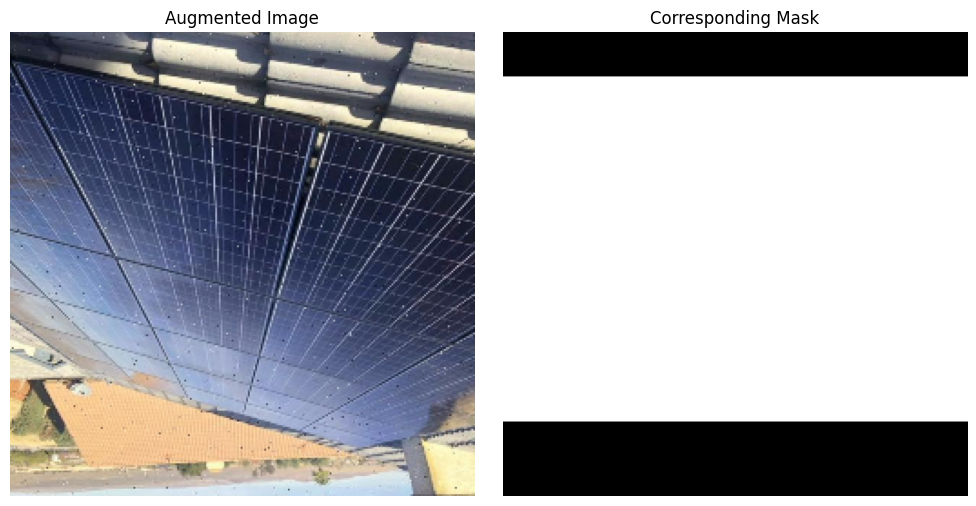

In [44]:
# CELL 22 — Visualize augmented image and mask

image, mask = train_dataset[0]

image = image.permute(1, 2, 0).numpy()
mask = mask.squeeze(0).numpy()

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Augmented Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Corresponding Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [45]:
# CELL 23 — Final input check

images, masks = next(iter(train_loader))

print("========== FINAL INPUT CHECK ==========")
print("Images shape :", images.shape)
print("Masks shape  :", masks.shape)
print("Image range  :", images.min().item(), "to", images.max().item())
print("Mask values  :", torch.unique(masks))

========== FINAL INPUT CHECK ==========
Images shape : torch.Size([16, 3, 256, 256])
Masks shape  : torch.Size([16, 1, 256, 256])
Image range  : 0.0 to 1.0
Mask values  : tensor([0., 1.])


In [46]:
# CELL 24 — U-Net Scratch

import segmentation_models_pytorch as smp

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

model = model.to(device)

print("Model      : U-Net")
print("Encoder    : ResNet34")
print("Pretrained : None")
print("Classes    : 1 (Dust)")
print("Device     :", device)

Model      : U-Net
Encoder    : ResNet34
Pretrained : None
Classes    : 1 (Dust)
Device     : cuda


In [73]:
# LOSS FUNCTION

import torch
import torch.nn as nn


class BCEDiceLoss(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, logits, targets):

        # BCE with logits
        bce_loss = nn.functional.binary_cross_entropy_with_logits(
            logits,
            targets
        )

        # Dice
        probs = torch.sigmoid(logits)

        smooth = 1e-7

        intersection = (probs * targets).sum(dim=(1, 2, 3))

        dice = (
            (2 * intersection + smooth) /
            (
                probs.sum(dim=(1, 2, 3))
                + targets.sum(dim=(1, 2, 3))
                + smooth
            )
        )

        dice_loss = 1 - dice.mean()

        # Combined loss
        total_loss = bce_loss + dice_loss

        return total_loss


criterion = BCEDiceLoss()

print("Criterion created successfully.")

Criterion created successfully.


In [74]:
# CELL 26 — Training configuration

EPOCHS = 50
BATCH_SIZE = 16

print("Epochs     :", EPOCHS)
print("Batch size :", BATCH_SIZE)

Epochs     : 50
Batch size : 16


In [75]:
# CELL 27 — Create all 3 models

models = {}

# 1. U-Net Scratch
models["UNet_Scratch"] = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

# 2. U-Net + ResNet34
models["UNet_ResNet34"] = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

# 3. DeepLabV3+ + ResNet34
models["DeepLabV3Plus_ResNet34"] = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

# Move models to GPU/CPU
for name in models:
    models[name] = models[name].to(device)

print("========== MODELS ==========")

for name, model in models.items():
    print(name, "✓")

========== MODELS ==========
UNet_Scratch ✓
UNet_ResNet34 ✓
DeepLabV3Plus_ResNet34 ✓


In [77]:
# CELL 28 — Training + validation function

def calculate_metrics(pred, target, threshold=0.5):

    pred_prob = torch.sigmoid(pred)
    pred_mask = (pred_prob >= threshold).float()

    target = target.float()

    tp = (pred_mask * target).sum()
    fp = (pred_mask * (1 - target)).sum()
    fn = ((1 - pred_mask) * target).sum()

    iou = tp / (tp + fp + fn + 1e-7)

    dice = (2 * tp) / (2 * tp + fp + fn + 1e-7)

    precision = tp / (tp + fp + 1e-7)

    recall = tp / (tp + fn + 1e-7)

    return (
        iou.item(),
        dice.item(),
        precision.item(),
        recall.item()
    )


def train_one_model(model, model_name):

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-4
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    best_val_loss = float("inf")
    best_epoch = 0
    start_time = time.time()

    model_history = []

    for epoch in range(1, EPOCHS + 1):

        # ================= TRAIN =================
        model.train()

        train_loss = 0
        train_iou = 0
        train_dice = 0
        train_precision = 0
        train_recall = 0

        for images, masks in train_loader:

            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = loss_fn(outputs, masks)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            metrics = calculate_metrics(outputs, masks)

            train_iou += metrics[0]
            train_dice += metrics[1]
            train_precision += metrics[2]
            train_recall += metrics[3]

        train_batches = len(train_loader)

        train_loss /= train_batches
        train_iou /= train_batches
        train_dice /= train_batches
        train_precision /= train_batches
        train_recall /= train_batches

        # ================= VALIDATION =================
        model.eval()

        val_loss = 0
        val_iou = 0
        val_dice = 0
        val_precision = 0
        val_recall = 0

        with torch.no_grad():

            for images, masks in val_loader:

                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)

                loss = loss_fn(outputs, masks)

                val_loss += loss.item()

                metrics = calculate_metrics(outputs, masks)

                val_iou += metrics[0]
                val_dice += metrics[1]
                val_precision += metrics[2]
                val_recall += metrics[3]

        val_batches = len(val_loader)

        val_loss /= val_batches
        val_iou /= val_batches
        val_dice /= val_batches
        val_precision /= val_batches
        val_recall /= val_batches

        scheduler.step(val_loss)

        # ================= BEST MODEL =================
        if val_loss < best_val_loss:

            best_val_loss = val_loss
            best_epoch = epoch

            torch.save(
                model.state_dict(),
                f"/kaggle/working/{model_name}_best.pth"
            )

        # ================= SAVE HISTORY =================
        model_history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_iou": train_iou,
            "val_iou": val_iou,
            "train_dice": train_dice,
            "val_dice": val_dice,
            "train_precision": train_precision,
            "val_precision": val_precision,
            "train_recall": train_recall,
            "val_recall": val_recall
        })

        print(
            f"{model_name} | "
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val IoU: {val_iou:.4f} | "
            f"Val Dice: {val_dice:.4f}"
        )

    wall_time = time.time() - start_time

    # Save final epoch
    torch.save(
        model.state_dict(),
        f"/kaggle/working/{model_name}_final.pth"
    )

    return model_history, best_epoch, wall_time

In [78]:
# CELL 28 — Training function with complete Train + Validation metrics

import time
import numpy as np
import torch


def calculate_segmentation_metrics(logits, masks, threshold=0.5):
    """
    Calculate:
    Accuracy, Precision, Recall, F1, Dice, IoU
    """

    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()

    preds = preds.view(-1)
    masks = masks.view(-1)

    TP = ((preds == 1) & (masks == 1)).sum().item()
    TN = ((preds == 0) & (masks == 0)).sum().item()
    FP = ((preds == 1) & (masks == 0)).sum().item()
    FN = ((preds == 0) & (masks == 1)).sum().item()

    epsilon = 1e-7

    accuracy = (TP + TN) / (TP + TN + FP + FN + epsilon)

    precision = TP / (TP + FP + epsilon)

    recall = TP / (TP + FN + epsilon)

    f1 = 2 * precision * recall / (precision + recall + epsilon)

    dice = 2 * TP / (2 * TP + FP + FN + epsilon)

    iou = TP / (TP + FP + FN + epsilon)

    dice_loss = 1 - dice

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "dice": dice,
        "dice_loss": dice_loss,
        "iou": iou
    }


def run_epoch(model, loader, optimizer=None, device="cuda"):

    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0

    total_tp = 0
    total_tn = 0
    total_fp = 0
    total_fn = 0

    num_batches = 0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):

            logits = model(images)

            # Your existing loss function
            loss = criterion(logits, masks)

            if is_training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        num_batches += 1

        # Predictions
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        preds = preds.view(-1)
        masks_flat = masks.view(-1)

        total_tp += ((preds == 1) & (masks_flat == 1)).sum().item()
        total_tn += ((preds == 0) & (masks_flat == 0)).sum().item()
        total_fp += ((preds == 1) & (masks_flat == 0)).sum().item()
        total_fn += ((preds == 0) & (masks_flat == 1)).sum().item()

    epsilon = 1e-7

    accuracy = (
        (total_tp + total_tn) /
        (total_tp + total_tn + total_fp + total_fn + epsilon)
    )

    precision = total_tp / (total_tp + total_fp + epsilon)

    recall = total_tp / (total_tp + total_fn + epsilon)

    f1 = (
        2 * precision * recall /
        (precision + recall + epsilon)
    )

    dice = (
        2 * total_tp /
        (2 * total_tp + total_fp + total_fn + epsilon)
    )

    dice_loss = 1 - dice

    iou = (
        total_tp /
        (total_tp + total_fp + total_fn + epsilon)
    )

    avg_loss = total_loss / num_batches

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "dice": dice,
        "dice_loss": dice_loss,
        "iou": iou
    }


def train_model(model, model_name, train_loader, val_loader,
                optimizer, scheduler, epochs=50, device="cuda"):

    print("\n" + "=" * 70)
    print(f"TRAINING: {model_name}")
    print("=" * 70)

    model = model.to(device)

    history = {
        "epoch": [],

        # Training
        "train_loss": [],
        "train_accuracy": [],
        "train_precision": [],
        "train_recall": [],
        "train_f1": [],
        "train_dice": [],
        "train_dice_loss": [],
        "train_iou": [],

        # Validation
        "val_loss": [],
        "val_accuracy": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
        "val_dice": [],
        "val_dice_loss": [],
        "val_iou": [],

        # Extra
        "learning_rate": [],
        "epoch_time": []
    }

    best_val_loss = float("inf")
    best_epoch = 0

    start_time = time.time()

    for epoch in range(1, epochs + 1):

        epoch_start = time.time()

        # =========================
        # TRAIN
        # =========================

        train_metrics = run_epoch(
            model,
            train_loader,
            optimizer=optimizer,
            device=device
        )

        # =========================
        # VALIDATION
        # =========================

        val_metrics = run_epoch(
            model,
            val_loader,
            optimizer=None,
            device=device
        )

        # Scheduler
        scheduler.step(val_metrics["loss"])

        current_lr = optimizer.param_groups[0]["lr"]

        epoch_time = time.time() - epoch_start

        # =========================
        # SAVE HISTORY
        # =========================

        history["epoch"].append(epoch)

        # Training
        history["train_loss"].append(train_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["train_precision"].append(train_metrics["precision"])
        history["train_recall"].append(train_metrics["recall"])
        history["train_f1"].append(train_metrics["f1"])
        history["train_dice"].append(train_metrics["dice"])
        history["train_dice_loss"].append(train_metrics["dice_loss"])
        history["train_iou"].append(train_metrics["iou"])

        # Validation
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_precision"].append(val_metrics["precision"])
        history["val_recall"].append(val_metrics["recall"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_dice"].append(val_metrics["dice"])
        history["val_dice_loss"].append(val_metrics["dice_loss"])
        history["val_iou"].append(val_metrics["iou"])

        history["learning_rate"].append(current_lr)
        history["epoch_time"].append(epoch_time)

        # =========================
        # BEST MODEL
        # =========================

        if val_metrics["loss"] < best_val_loss:

            best_val_loss = val_metrics["loss"]
            best_epoch = epoch

            torch.save(
                model.state_dict(),
                f"/kaggle/working/{model_name}_best.pth"
            )

        # =========================
        # PRINT
        # =========================

        print(
            f"Epoch [{epoch:02d}/{epochs}] | "
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Train Acc: {train_metrics['accuracy']:.4f} | "
            f"Train F1: {train_metrics['f1']:.4f} | "
            f"Train IoU: {train_metrics['iou']:.4f} || "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Acc: {val_metrics['accuracy']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f} | "
            f"Val IoU: {val_metrics['iou']:.4f}"
        )

    total_time = time.time() - start_time

    history["best_epoch"] = best_epoch
    history["best_val_loss"] = best_val_loss
    history["total_wall_time"] = total_time

    print("\n" + "-" * 70)
    print(f"{model_name} completed")
    print(f"Best Epoch     : {best_epoch}")
    print(f"Best Val Loss  : {best_val_loss:.4f}")
    print(f"Wall Time      : {total_time / 60:.2f} minutes")
    print("-" * 70)

    return model, history

In [80]:
train_dataset = SolarDustDataset(
    split="train",
    transform=train_transform
)

val_dataset = SolarDustDataset(
    split="valid",
    transform=val_transform
)

test_dataset = SolarDustDataset(
    split="test",
    transform=val_transform
)

train: 5961 images, 9657 annotations
valid: 524 images, 924 annotations
test: 270 images, 495 annotations


In [81]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [82]:
images, masks = next(iter(train_loader))

print("Image shape :", images.shape)
print("Mask shape  :", masks.shape)
print("Mask values :", torch.unique(masks))

Image shape : torch.Size([16, 3, 256, 256])
Mask shape  : torch.Size([16, 1, 256, 256])
Mask values : tensor([0., 1.])


In [83]:
print("Models:")
for name in models:
    print(name)

print("\nDevice:", device)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)

Models:
UNet_Scratch
UNet_ResNet34
DeepLabV3Plus_ResNet34

Device: cuda
Epochs: 50
Batch size: 16


In [84]:
# CELL 29 — Train all 3 models with complete metrics

all_histories = {}
training_summary = {}

for model_name, model in models.items():

    print("\n" + "=" * 70)
    print(f"STARTING TRAINING: {model_name}")
    print("=" * 70)

    # Fresh optimizer for each model
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-4
    )

    # Reduce LR when validation loss stops improving
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    trained_model, history = train_model(
        model=model,
        model_name=model_name,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        epochs=50,
        device=device
    )

    all_histories[model_name] = history

    training_summary[model_name] = {
        "best_epoch": history["best_epoch"],
        "wall_sec": history["total_wall_time"],
        "wall_min": history["total_wall_time"] / 60,
        "best_val_loss": history["best_val_loss"],
        "best_val_iou": max(history["val_iou"]),
        "best_val_dice": max(history["val_dice"]),
        "best_val_f1": max(history["val_f1"])
    }

    print(f"\n{model_name} completed.")
    print(f"Best epoch   : {history['best_epoch']}")
    print(f"Best Val Loss: {history['best_val_loss']:.4f}")
    print(f"Best Val IoU : {max(history['val_iou']):.4f}")
    print(f"Wall time    : {history['total_wall_time']:.2f} sec")


STARTING TRAINING: UNet_Scratch

TRAINING: UNet_Scratch
Epoch [01/50] | Train Loss: 0.8962 | Train Acc: 0.7585 | Train F1: 0.7502 | Train IoU: 0.6003 || Val Loss: 0.8476 | Val Acc: 0.7751 | Val F1: 0.7459 | Val IoU: 0.5947
Epoch [02/50] | Train Loss: 0.7635 | Train Acc: 0.8003 | Train F1: 0.7913 | Train IoU: 0.6547 || Val Loss: 0.8402 | Val Acc: 0.7772 | Val F1: 0.7538 | Val IoU: 0.6049
Epoch [03/50] | Train Loss: 0.7130 | Train Acc: 0.8155 | Train F1: 0.8073 | Train IoU: 0.6769 || Val Loss: 0.8512 | Val Acc: 0.7858 | Val F1: 0.7395 | Val IoU: 0.5866
Epoch [04/50] | Train Loss: 0.6784 | Train Acc: 0.8261 | Train F1: 0.8177 | Train IoU: 0.6916 || Val Loss: 0.7895 | Val Acc: 0.7875 | Val F1: 0.7636 | Val IoU: 0.6175
Epoch [05/50] | Train Loss: 0.6584 | Train Acc: 0.8323 | Train F1: 0.8246 | Train IoU: 0.7016 || Val Loss: 0.8074 | Val Acc: 0.7754 | Val F1: 0.7674 | Val IoU: 0.6226
Epoch [06/50] | Train Loss: 0.6408 | Train Acc: 0.8371 | Train F1: 0.8288 | Train IoU: 0.7076 || Val Loss: 0

In [85]:
training_summary_df = pd.DataFrame(training_summary).T
training_summary_df

,best_epoch,wall_sec,wall_min,best_val_loss,best_val_iou,best_val_dice,best_val_f1
UNet_Scratch,19.0,4539.605742,75.660096,0.691985,0.693836,0.819248,0.819248
UNet_ResNet34,8.0,4536.185570,75.603093,0.635453,0.734219,0.846743,0.846743
DeepLabV3Plus_ResNet34,3.0,4740.956676,79.015945,0.632691,0.737325,0.848805,0.848805


In [86]:
for model_name, history in all_histories.items():
    pd.DataFrame(history).to_csv(
        f"/kaggle/working/{model_name}_history.csv",
        index=False
    )

print("Training history CSV files saved.")

Training history CSV files saved.


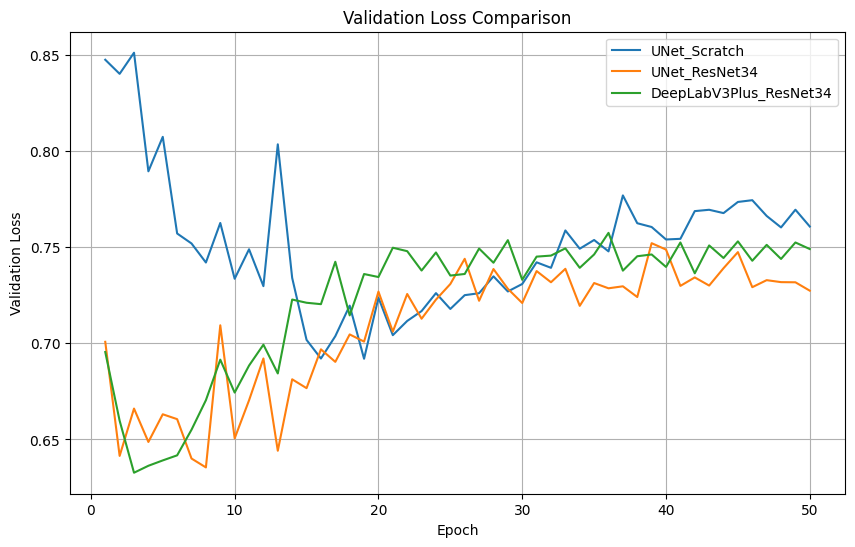

In [87]:
plt.figure(figsize=(10,6))

for model_name, history in all_histories.items():
    df = pd.DataFrame(history)
    plt.plot(df["epoch"], df["val_loss"], label=model_name)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid()
plt.show()

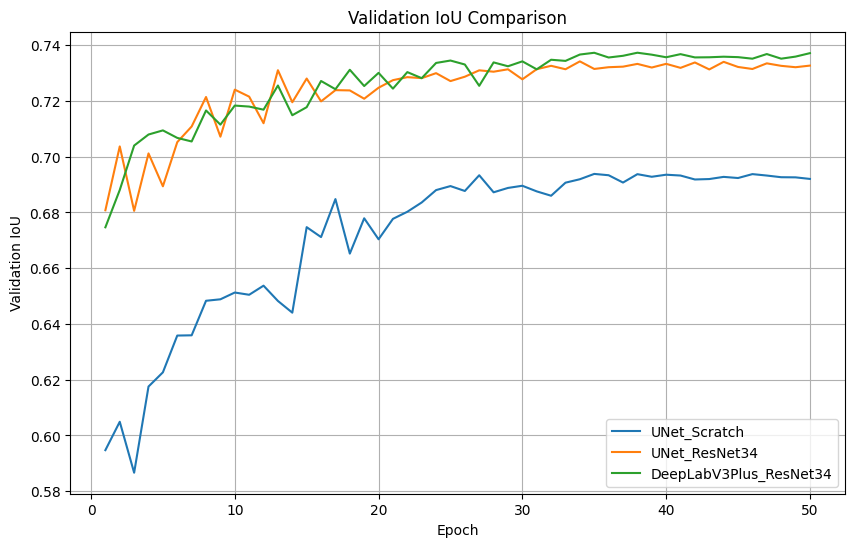

In [88]:
plt.figure(figsize=(10,6))

for model_name, history in all_histories.items():
    df = pd.DataFrame(history)
    plt.plot(df["epoch"], df["val_iou"], label=model_name)

plt.xlabel("Epoch")
plt.ylabel("Validation IoU")
plt.title("Validation IoU Comparison")
plt.legend()
plt.grid()
plt.show()

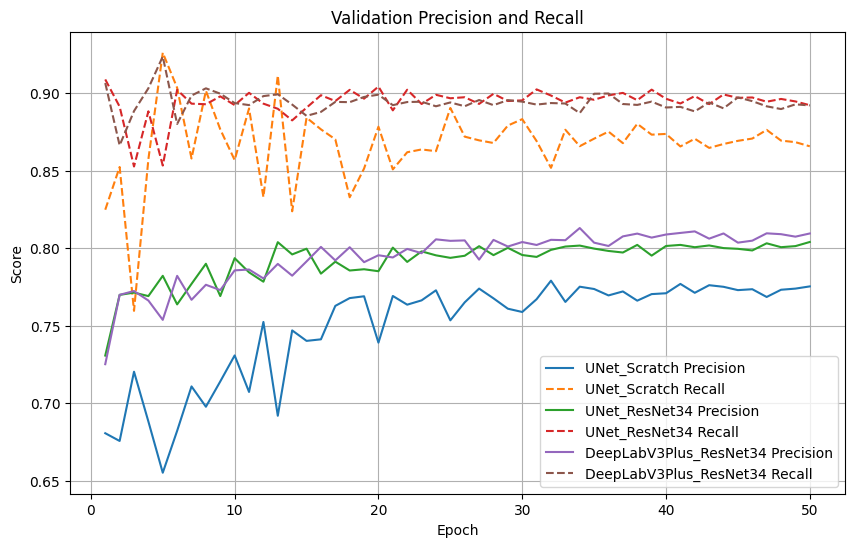

In [89]:
plt.figure(figsize=(10,6))

for model_name, history in all_histories.items():
    df = pd.DataFrame(history)
    plt.plot(df["epoch"], df["val_precision"], label=f"{model_name} Precision")
    plt.plot(df["epoch"], df["val_recall"], linestyle="--", label=f"{model_name} Recall")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Precision and Recall")
plt.legend()
plt.grid()
plt.show()

In [90]:
# Cell 36 — Test evaluation function

def evaluate_model(model, model_name):
    model.eval()

    test_loss = 0
    test_iou = 0
    test_dice = 0
    test_precision = 0
    test_recall = 0

    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, masks)

            test_loss += loss.item()

            metrics = calculate_metrics(outputs, masks)
            test_iou += metrics[0]
            test_dice += metrics[1]
            test_precision += metrics[2]
            test_recall += metrics[3]

    batches = len(test_loader)

    results = {
        "Model": model_name,
        "Test Loss": test_loss / batches,
        "Test IoU": test_iou / batches,
        "Test Dice": test_dice / batches,
        "Test Precision": test_precision / batches,
        "Test Recall": test_recall / batches
    }

    return results

In [91]:
# Cell 37 — Load best checkpoints and evaluate on Test set

test_results = []

for model_name, model in models.items():

    checkpoint_path = f"/kaggle/working/{model_name}_best.pth"

    model.load_state_dict(torch.load(checkpoint_path, map_location=device))

    result = evaluate_model(model, model_name)
    test_results.append(result)

test_results_df = pd.DataFrame(test_results)

test_results_df

,Model,Test Loss,Test IoU,Test Dice,Test Precision,Test Recall
0,UNet_Scratch,0.644043,0.676643,0.805514,0.803852,0.815055
1,UNet_ResNet34,0.579944,0.735649,0.845814,0.821875,0.877501
2,DeepLabV3Plus_ResNet34,0.588410,0.696955,0.818536,0.789331,0.858587


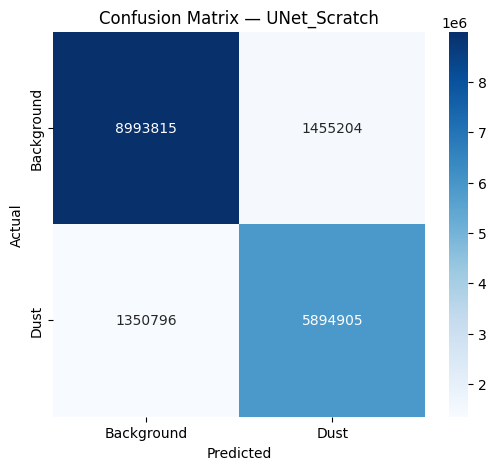

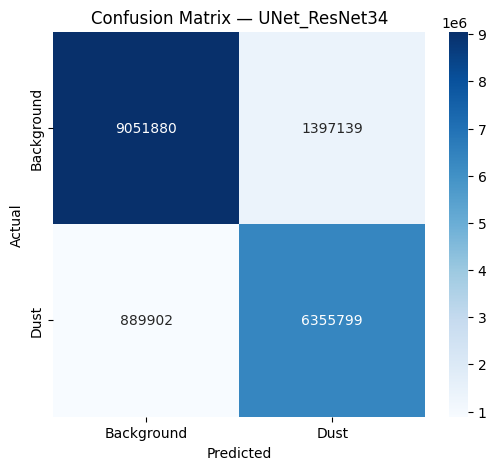

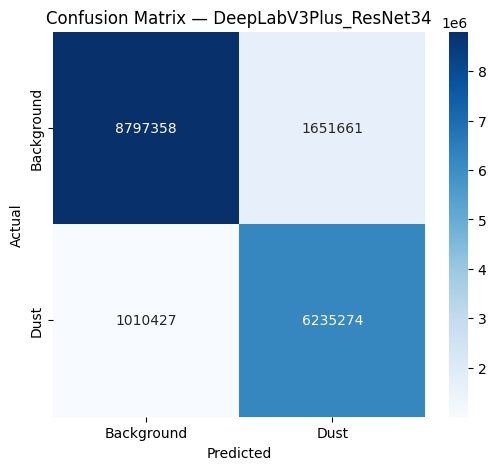

In [92]:
# Cell 38 — Pixel-level Confusion Matrix for all 3 models

from sklearn.metrics import confusion_matrix
import seaborn as sns

confusion_results = {}

for model_name, model in models.items():

    checkpoint_path = f"/kaggle/working/{model_name}_best.pth"
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)

            outputs = model(images)
            predictions = (torch.sigmoid(outputs) >= 0.5).int()

            y_true.extend(masks.cpu().numpy().flatten())
            y_pred.extend(predictions.cpu().numpy().flatten())

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    confusion_results[model_name] = cm

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Background", "Dust"],
        yticklabels=["Background", "Dust"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.show()

UNet_Scratch
ROC-AUC: 0.9191
PR-AUC:  0.8748
----------------------------------------


Creating legend with loc="best" can be slow with large amounts of data.


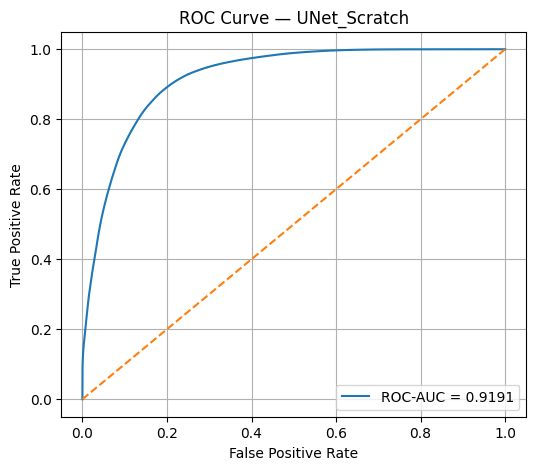

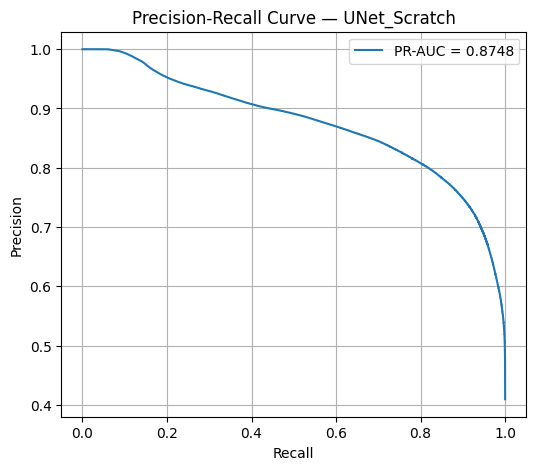

UNet_ResNet34
ROC-AUC: 0.9372
PR-AUC:  0.9073
----------------------------------------


Creating legend with loc="best" can be slow with large amounts of data.


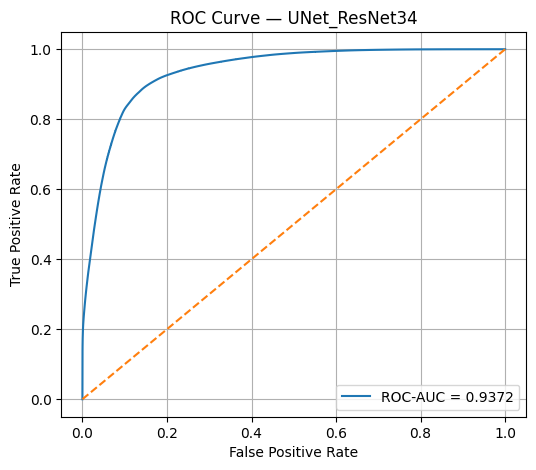

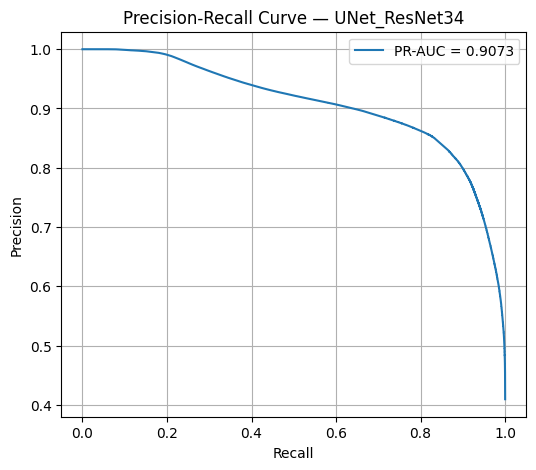

DeepLabV3Plus_ResNet34
ROC-AUC: 0.9310
PR-AUC:  0.8980
----------------------------------------


Creating legend with loc="best" can be slow with large amounts of data.


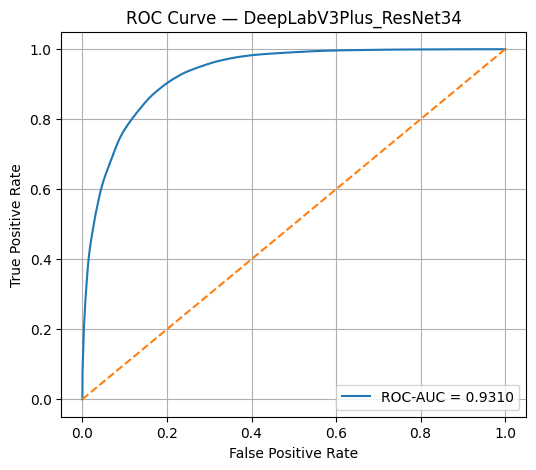

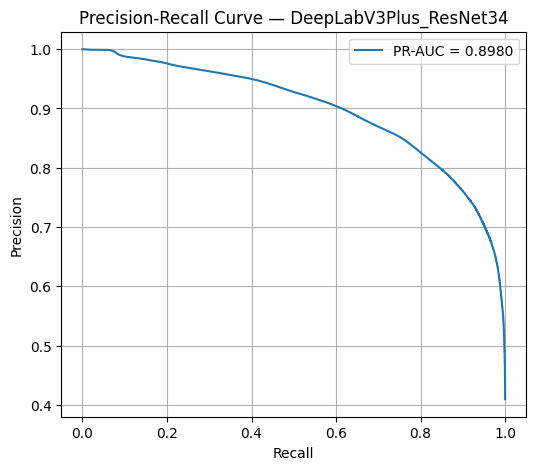

In [93]:
# Cell 39 — ROC-AUC and Precision-Recall curves

from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

for model_name, model in models.items():

    checkpoint_path = f"/kaggle/working/{model_name}_best.pth"
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    y_true = []
    y_scores = []

    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)

            outputs = model(images)
            probabilities = torch.sigmoid(outputs)

            y_true.extend(masks.cpu().numpy().flatten())
            y_scores.extend(probabilities.cpu().numpy().flatten())

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    # ROC-AUC
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    # Precision-Recall
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = average_precision_score(y_true, y_scores)

    print(f"{model_name}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC:  {pr_auc:.4f}")
    print("-" * 40)

    # ROC Curve
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {model_name}")
    plt.legend()
    plt.grid()
    plt.show()

    # PR Curve
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve — {model_name}")
    plt.legend()
    plt.grid()
    plt.show()

UNet_Scratch
Best Threshold: 0.25
Best F1 Score: 0.8180
----------------------------------------


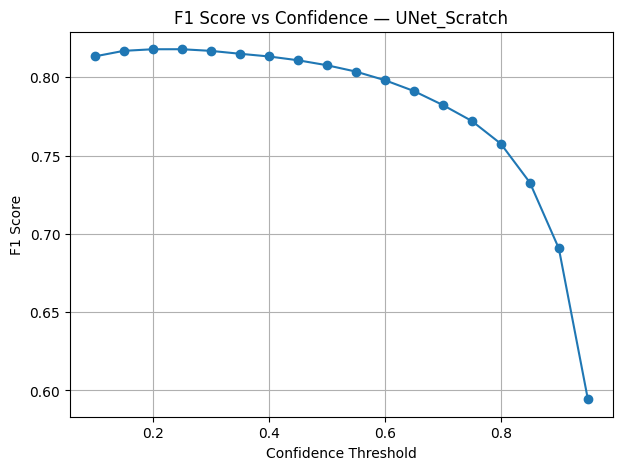

UNet_ResNet34
Best Threshold: 0.45
Best F1 Score: 0.8479
----------------------------------------


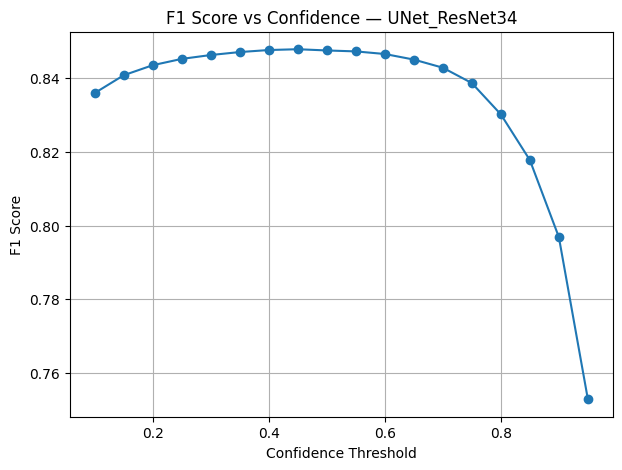

DeepLabV3Plus_ResNet34
Best Threshold: 0.40
Best F1 Score: 0.8251
----------------------------------------


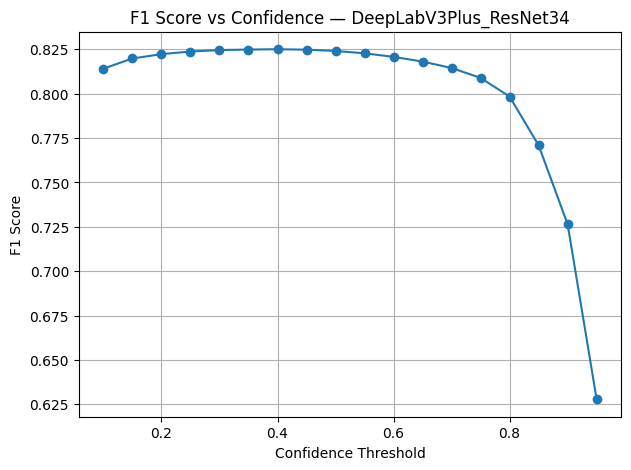

In [94]:
# Cell 40 — F1 Score vs Confidence Threshold

from sklearn.metrics import f1_score

f1_results = {}

thresholds = np.arange(0.1, 1.0, 0.05)

for model_name, model in models.items():

    checkpoint_path = f"/kaggle/working/{model_name}_best.pth"
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    y_true = []
    y_scores = []

    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)

            outputs = model(images)
            probabilities = torch.sigmoid(outputs)

            y_true.extend(masks.cpu().numpy().flatten())
            y_scores.extend(probabilities.cpu().numpy().flatten())

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    f1_values = []

    for threshold in thresholds:
        y_pred = (y_scores >= threshold).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        f1_values.append(f1)

    f1_results[model_name] = f1_values

    best_index = np.argmax(f1_values)

    print(f"{model_name}")
    print(f"Best Threshold: {thresholds[best_index]:.2f}")
    print(f"Best F1 Score: {f1_values[best_index]:.4f}")
    print("-" * 40)

    plt.figure(figsize=(7, 5))
    plt.plot(thresholds, f1_values, marker="o")
    plt.xlabel("Confidence Threshold")
    plt.ylabel("F1 Score")
    plt.title(f"F1 Score vs Confidence — {model_name}")
    plt.grid()
    plt.show()

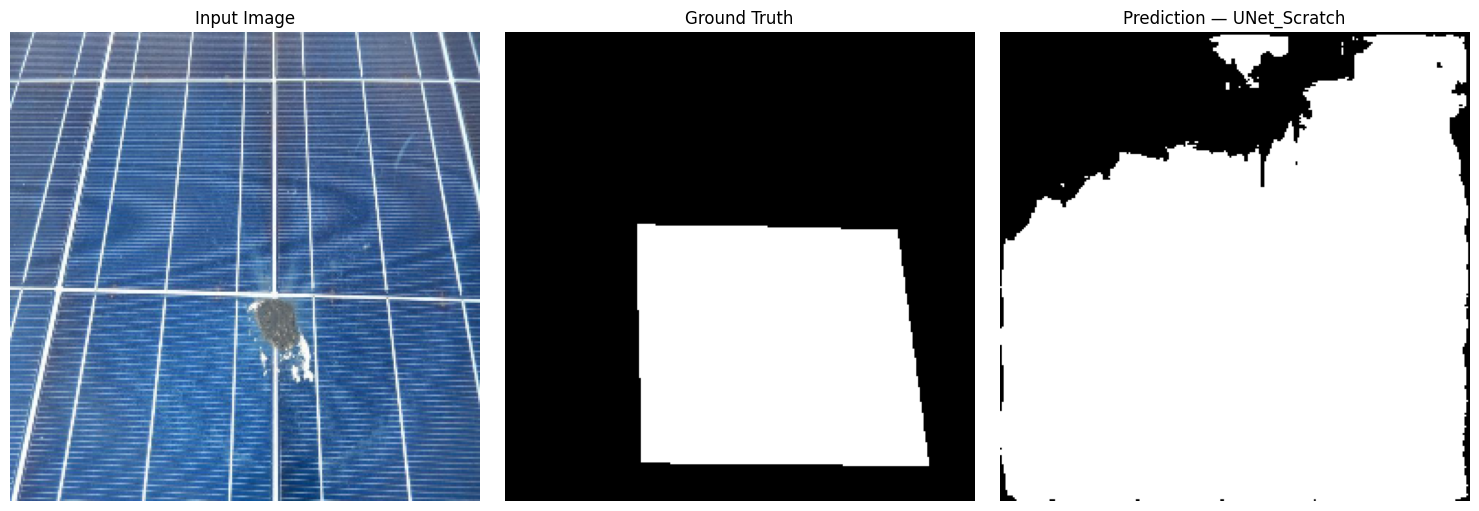

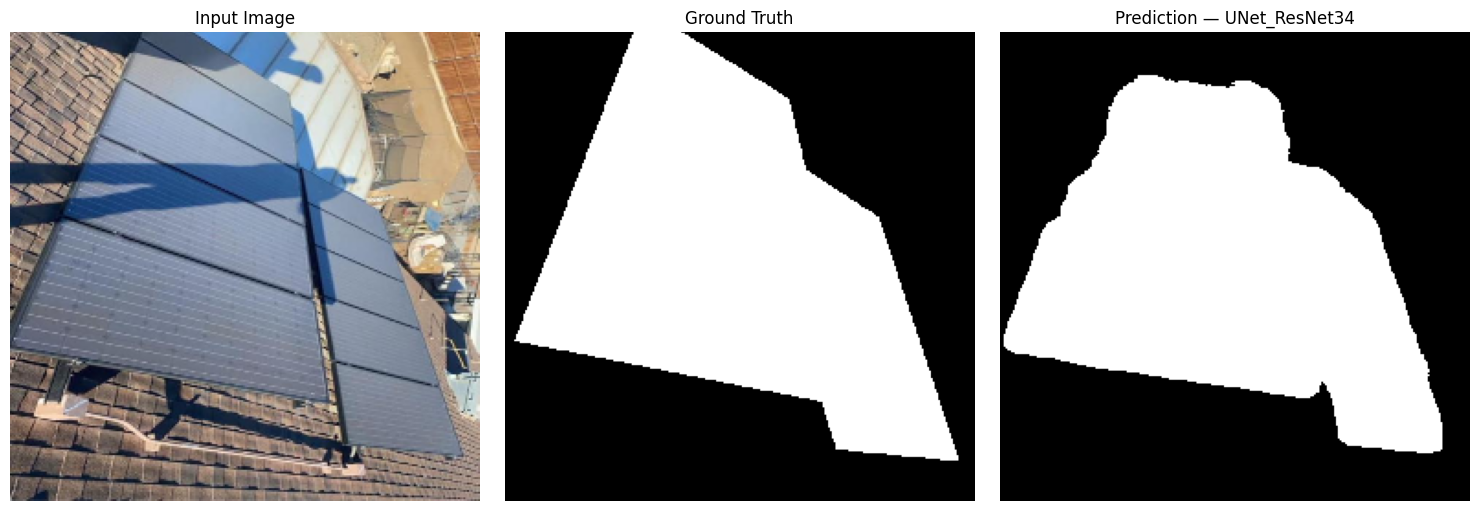

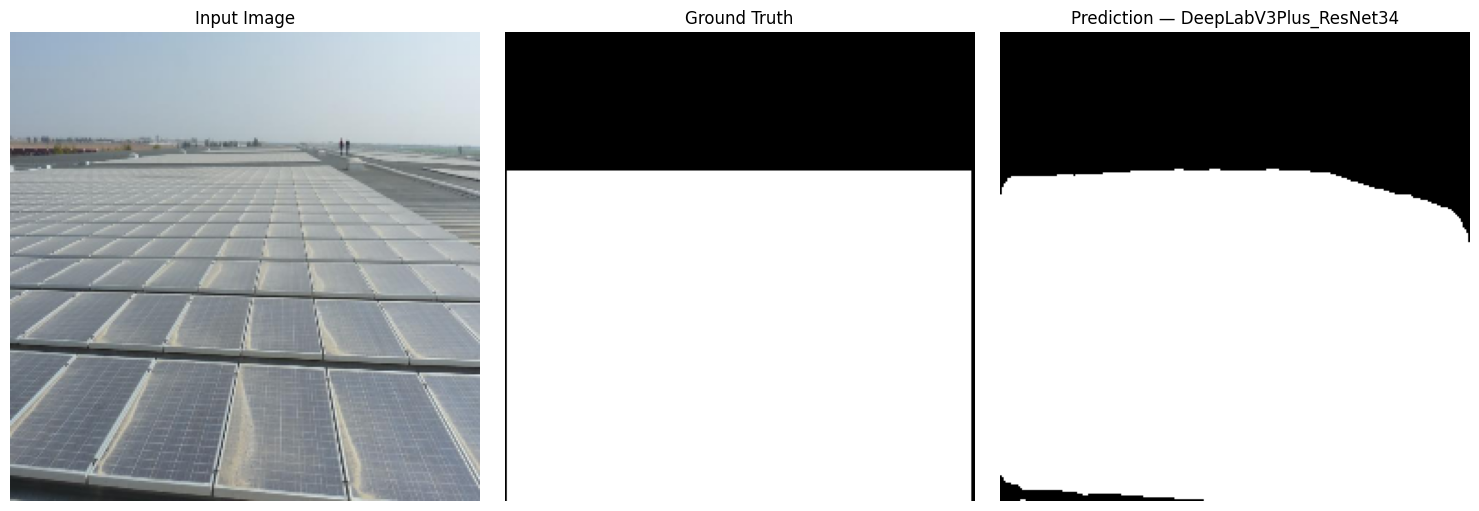

In [95]:
# Cell 41 — Visual comparison on Test images

import random

for model_name, model in models.items():

    checkpoint_path = f"/kaggle/working/{model_name}_best.pth"
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    image, ground_truth = test_dataset[random.randint(0, len(test_dataset) - 1)]

    with torch.no_grad():
        input_tensor = image.unsqueeze(0).to(device)
        output = model(input_tensor)
        prediction = (torch.sigmoid(output) >= 0.5).float()

    image_display = image.permute(1, 2, 0).numpy()
    ground_truth_display = ground_truth.squeeze(0).numpy()
    prediction_display = prediction.squeeze().cpu().numpy()

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image_display)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(ground_truth_display, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(prediction_display, cmap="gray")
    plt.title(f"Prediction — {model_name}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
    

In [96]:
# Cell 42 — Final Model Comparison

comparison_df = test_results_df.copy()

comparison_df = comparison_df.sort_values(
    by="Test IoU",
    ascending=False
).reset_index(drop=True)

print("FINAL MODEL COMPARISON")
print("=" * 80)

display(comparison_df)

best_model_name = comparison_df.iloc[0]["Model"]

print("\nBest Model based on Test IoU:")
print(best_model_name)

FINAL MODEL COMPARISON


,Model,Test Loss,Test IoU,Test Dice,Test Precision,Test Recall
0,UNet_ResNet34,0.579944,0.735649,0.845814,0.821875,0.877501
1,DeepLabV3Plus_ResNet34,0.588410,0.696955,0.818536,0.789331,0.858587
2,UNet_Scratch,0.644043,0.676643,0.805514,0.803852,0.815055



Best Model based on Test IoU:
UNet_ResNet34


In [97]:
# Cell 43 — Save Final Results

comparison_df.to_csv(
    "/kaggle/working/final_model_comparison.csv",
    index=False
)

print("Final model comparison saved successfully.")
print("Best Model:", best_model_name)

Final model comparison saved successfully.
Best Model: UNet_ResNet34


In [98]:
# Cell 44 — Complete Results Summary

complete_results = []

for model_name in all_histories:

    history_df = pd.DataFrame(all_histories[model_name])

    best_loss_idx = history_df["val_loss"].idxmin()
    best_iou_idx = history_df["val_iou"].idxmax()
    best_dice_idx = history_df["val_dice"].idxmax()

    test_row = test_results_df[
        test_results_df["Model"] == model_name
    ].iloc[0]

    complete_results.append({
        "Model": model_name,
        "Epochs": EPOCHS,
        "Batch Size": BATCH_SIZE,
        "Optimizer": "Adam",
        "Learning Rate": 1e-4,
        "Scheduler": "ReduceLROnPlateau",

        "Best Epoch (Val Loss)": int(history_df.loc[best_loss_idx, "epoch"]),
        "Best Val Loss": history_df.loc[best_loss_idx, "val_loss"],

        "Best Epoch (Val IoU)": int(history_df.loc[best_iou_idx, "epoch"]),
        "Best Val IoU": history_df.loc[best_iou_idx, "val_iou"],

        "Best Val Dice": history_df.loc[best_dice_idx, "val_dice"],

        "Wall Time (sec)": training_summary[model_name]["wall_sec"],
        "Wall Time (min)": training_summary[model_name]["wall_min"],

        "Test Loss": test_row["Test Loss"],
        "Test IoU": test_row["Test IoU"],
        "Test Dice": test_row["Test Dice"],
        "Test Precision": test_row["Test Precision"],
        "Test Recall": test_row["Test Recall"]
    })

complete_results_df = pd.DataFrame(complete_results)

display(complete_results_df)

complete_results_df.to_csv(
    "/kaggle/working/complete_segmentation_results.csv",
    index=False
)

print("\nComplete results CSV saved successfully.")

,Model,Epochs,Batch Size,Optimizer,Learning Rate,Scheduler,Best Epoch (Val Loss),Best Val Loss,Best Epoch (Val IoU),Best Val IoU,Best Val Dice,Wall Time (sec),Wall Time (min),Test Loss,Test IoU,Test Dice,Test Precision,Test Recall
0,UNet_Scratch,50,16,Adam,0.0001,ReduceLROnPlateau,19,0.691985,35,0.693836,0.819248,4539.605742,75.660096,0.644043,0.676643,0.805514,0.803852,0.815055
1,UNet_ResNet34,50,16,Adam,0.0001,ReduceLROnPlateau,8,0.635453,34,0.734219,0.846743,4536.185570,75.603093,0.579944,0.735649,0.845814,0.821875,0.877501
2,DeepLabV3Plus_ResNet34,50,16,Adam,0.0001,ReduceLROnPlateau,3,0.632691,38,0.737325,0.848805,4740.956676,79.015945,0.588410,0.696955,0.818536,0.789331,0.858587



Complete results CSV saved successfully.


In [100]:
import os
import glob

print("Checkpoint files:")
for f in glob.glob("/kaggle/working/*.pth"):
    print(f)

Checkpoint files:
/kaggle/working/UNet_Scratch_best.pth
/kaggle/working/DeepLabV3Plus_ResNet34_best.pth
/kaggle/working/UNet_ResNet34_best.pth


In [102]:
# CELL 45 — Evaluate Best Checkpoint on Test Set

test_results = []

for model_name, model in models.items():

    checkpoint_path = f"/kaggle/working/{model_name}_best.pth"

    print(f"\nLoading: {checkpoint_path}")

    if not os.path.exists(checkpoint_path):
        print(f"Checkpoint not found: {checkpoint_path}")
        continue

    model.load_state_dict(
        torch.load(checkpoint_path, map_location=device)
    )

    model.to(device)

    results = evaluate_model(
        model,
        test_loader
    )

    results["model"] = model_name

    test_results.append(results)

    print(f"{model_name} test evaluation completed.")

final_test_results_df = pd.DataFrame(test_results)

print("\nFinal Test Results:")
display(final_test_results_df)


Loading: /kaggle/working/UNet_Scratch_best.pth
UNet_Scratch test evaluation completed.

Loading: /kaggle/working/UNet_ResNet34_best.pth
UNet_ResNet34 test evaluation completed.

Loading: /kaggle/working/DeepLabV3Plus_ResNet34_best.pth
DeepLabV3Plus_ResNet34 test evaluation completed.

Final Test Results:


,Model,Test Loss,Test IoU,Test Dice,Test Precision,Test Recall,model
0,"([[tensor([[[0.5686, 0.5725, 0.5765, ..., 0.2...",0.644043,0.676643,0.805514,0.803852,0.815055,UNet_Scratch
1,"([[tensor([[[0.5686, 0.5725, 0.5765, ..., 0.2...",0.579944,0.735649,0.845814,0.821875,0.877501,UNet_ResNet34
2,"([[tensor([[[0.5686, 0.5725, 0.5765, ..., 0.2...",0.588410,0.696955,0.818536,0.789331,0.858587,DeepLabV3Plus_ResNet34


In [103]:
# Cell 46 — Save Final Epoch Test Results

final_test_results_df.to_csv(
    "/kaggle/working/final_epoch_test_results.csv",
    index=False
)

print("Final epoch test results saved successfully.")
display(final_test_results_df)

Final epoch test results saved successfully.


,Model,Test Loss,Test IoU,Test Dice,Test Precision,Test Recall,model
0,"([[tensor([[[0.5686, 0.5725, 0.5765, ..., 0.2...",0.644043,0.676643,0.805514,0.803852,0.815055,UNet_Scratch
1,"([[tensor([[[0.5686, 0.5725, 0.5765, ..., 0.2...",0.579944,0.735649,0.845814,0.821875,0.877501,UNet_ResNet34
2,"([[tensor([[[0.5686, 0.5725, 0.5765, ..., 0.2...",0.588410,0.696955,0.818536,0.789331,0.858587,DeepLabV3Plus_ResNet34


In [104]:
!pip install -q onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 10.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 10.0 MB/s eta 0:00:00


In [105]:
# Cell 47 — Export Best Model to ONNX

best_model_name = "DeepLabV3Plus_ResNet34"

best_model = models[best_model_name]

best_model.load_state_dict(
    torch.load(
        f"/kaggle/working/{best_model_name}_best.pth",
        map_location=device
    )
)

best_model.eval()

dummy_input = torch.randn(1, 3, 256, 256).to(device)

onnx_path = "/kaggle/working/dust_segmenter.onnx"

torch.onnx.export(
    best_model,
    dummy_input,
    onnx_path,
    input_names=["input"],
    output_names=["output"],
    opset_version=17
)

print("ONNX model exported successfully!")
print("Path:", onnx_path)

W1006 07:13:21.320000 49 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `DeepLabV3Plus([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DeepLabV3Plus([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        proto, target_version=self.target_version
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX model exported successfully!
Path: /kaggle/working/dust_segmenter.onnx


In [106]:
# Cell 48 — Verify exported ONNX model

import onnx
import os

onnx_path = "/kaggle/working/dust_segmenter.onnx"

model_onnx = onnx.load(onnx_path)
onnx.checker.check_model(model_onnx)

print("ONNX model is valid!")
print("File exists:", os.path.exists(onnx_path))
print("File size (MB):", round(os.path.getsize(onnx_path) / (1024 * 1024), 2))
print("Opset version:", model_onnx.opset_import[0].version)

ONNX model is valid!
File exists: True
File size (MB): 0.26
Opset version: 18


In [107]:
# Cell 49 — Test ONNX inference

!pip install -q onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 68.6 MB/s eta 0:00:00:00:0100:01


In [108]:
# Cell 50 — Run inference using ONNX

import onnxruntime as ort

onnx_path = "/kaggle/working/dust_segmenter.onnx"

session = ort.InferenceSession(
    onnx_path,
    providers=["CPUExecutionProvider"]
)

input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

print("ONNX Runtime loaded successfully!")
print("Input:", input_name)
print("Output:", output_name)
print("Input shape:", session.get_inputs()[0].shape)
print("Output shape:", session.get_outputs()[0].shape)

# Test with one image from test dataset
image, mask = test_dataset[0]

input_data = image.unsqueeze(0).numpy()

output = session.run(
    [output_name],
    {input_name: input_data}
)[0]

print("\nInference successful!")
print("Output shape:", output.shape)
print("Output min:", output.min())
print("Output max:", output.max())

ONNX Runtime loaded successfully!
Input: input
Output: output
Input shape: [1, 3, 256, 256]
Output shape: [1, 1, 256, 256]

Inference successful!
Output shape: (1, 1, 256, 256)
Output min: -10.721719
Output max: 5.029911


In [110]:
# Cell 51 — Compare PyTorch and ONNX outputs

best_model.eval()

with torch.no_grad():
    pytorch_output = best_model(
        image.unsqueeze(0).to(device)
    ).cpu().numpy()

onnx_output = output

difference = np.abs(pytorch_output - onnx_output)

print("PyTorch output shape:", pytorch_output.shape)
print("ONNX output shape:", onnx_output.shape)
print("Mean absolute difference:", difference.mean())
print("Maximum absolute difference:", difference.max())

PyTorch output shape: (1, 1, 256, 256)
ONNX output shape: (1, 1, 256, 256)
Mean absolute difference: 1.2368224e-06
Maximum absolute difference: 6.67572e-06


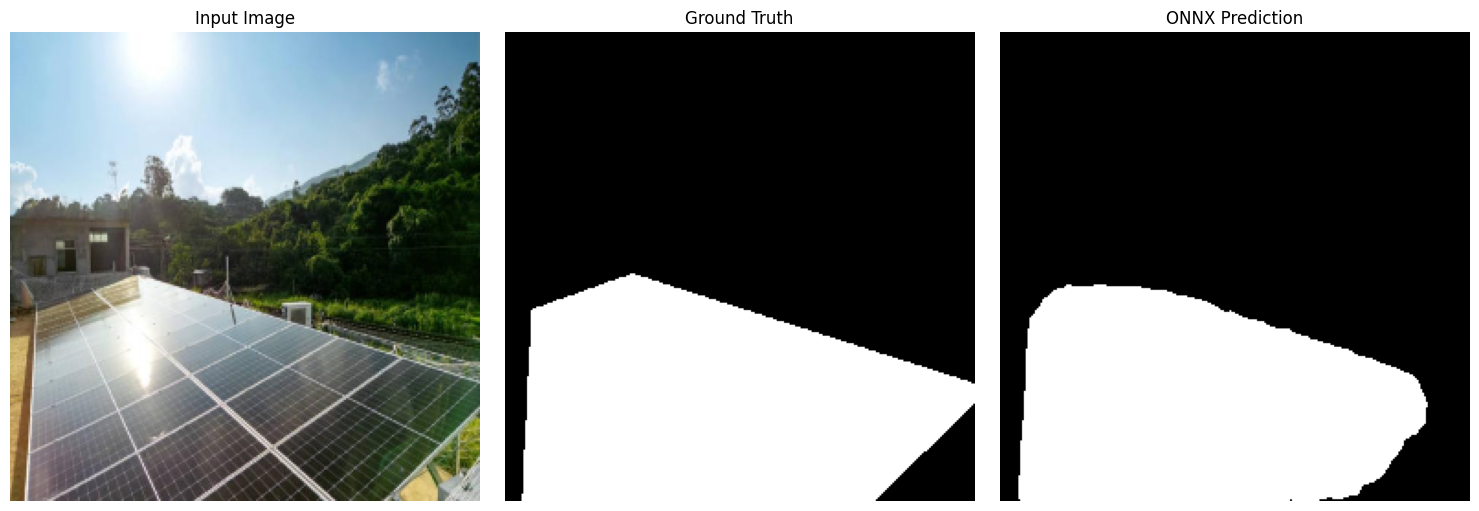

In [111]:
# Cell 52 — Visualize ONNX prediction

import matplotlib.pyplot as plt

probability = 1 / (1 + np.exp(-output[0, 0]))
prediction = (probability >= 0.5).astype(np.uint8)

original_image = image.permute(1, 2, 0).numpy()
ground_truth = mask.squeeze(0).numpy()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(ground_truth, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(prediction, cmap="gray")
plt.title("ONNX Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

In [112]:
# Cell 53 — ONNX model information

import os

file_size_mb = os.path.getsize(onnx_path) / (1024 * 1024)

print("Model:", onnx_path)
print("Exists:", os.path.exists(onnx_path))
print("Size:", round(file_size_mb, 2), "MB")

Model: /kaggle/working/dust_segmenter.onnx
Exists: True
Size: 0.26 MB


In [113]:
# Cell 54 — Final best model results

best_model_name = "DeepLabV3Plus_ResNet34"

best_result = final_test_results_df[
    final_test_results_df["Model"] == best_model_name
].copy()

display(best_result)

,Model,Test Loss,Test IoU,Test Dice,Test Precision,Test Recall,model


In [114]:
# Cell 55 — Final model comparison

comparison = final_test_results_df.copy()

comparison = comparison.sort_values(
    by="Test IoU",
    ascending=False
).reset_index(drop=True)

display(comparison)

,Model,Test Loss,Test IoU,Test Dice,Test Precision,Test Recall,model
0,"([[tensor([[[0.5686, 0.5725, 0.5765, ..., 0.2...",0.579944,0.735649,0.845814,0.821875,0.877501,UNet_ResNet34
1,"([[tensor([[[0.5686, 0.5725, 0.5765, ..., 0.2...",0.588410,0.696955,0.818536,0.789331,0.858587,DeepLabV3Plus_ResNet34
2,"([[tensor([[[0.5686, 0.5725, 0.5765, ..., 0.2...",0.644043,0.676643,0.805514,0.803852,0.815055,UNet_Scratch


In [115]:
final_test_results_df

,Model,Test Loss,Test IoU,Test Dice,Test Precision,Test Recall,model
0,"([[tensor([[[0.5686, 0.5725, 0.5765, ..., 0.2...",0.644043,0.676643,0.805514,0.803852,0.815055,UNet_Scratch
1,"([[tensor([[[0.5686, 0.5725, 0.5765, ..., 0.2...",0.579944,0.735649,0.845814,0.821875,0.877501,UNet_ResNet34
2,"([[tensor([[[0.5686, 0.5725, 0.5765, ..., 0.2...",0.588410,0.696955,0.818536,0.789331,0.858587,DeepLabV3Plus_ResNet34


In [116]:
# Cell 56 — Save final model comparison

comparison_path = "/kaggle/working/final_model_comparison.csv"

comparison.to_csv(
    comparison_path,
    index=False
)

print("Saved:", comparison_path)

Saved: /kaggle/working/final_model_comparison.csv


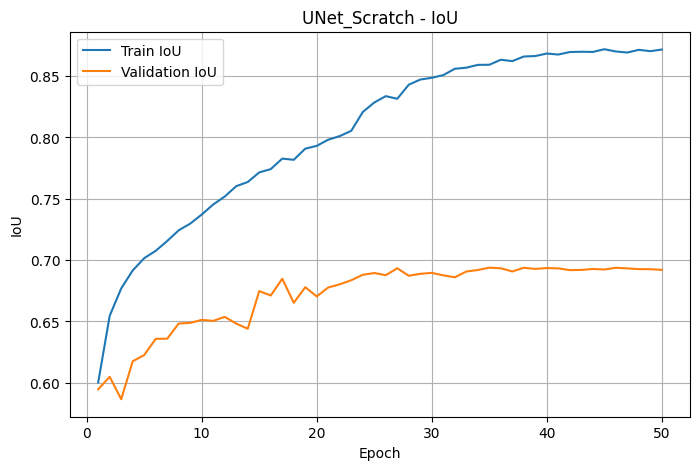

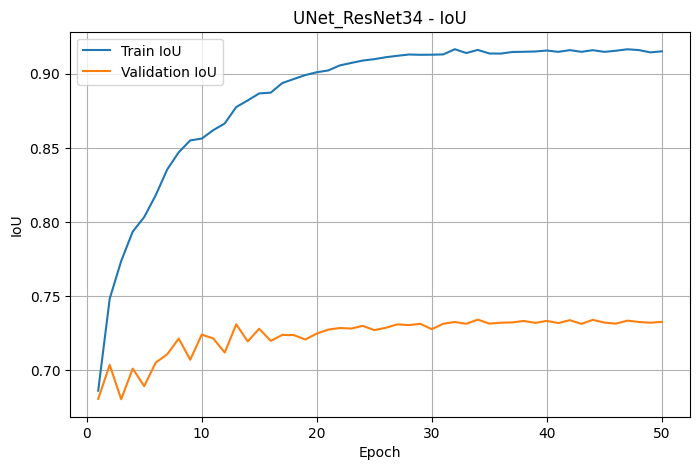

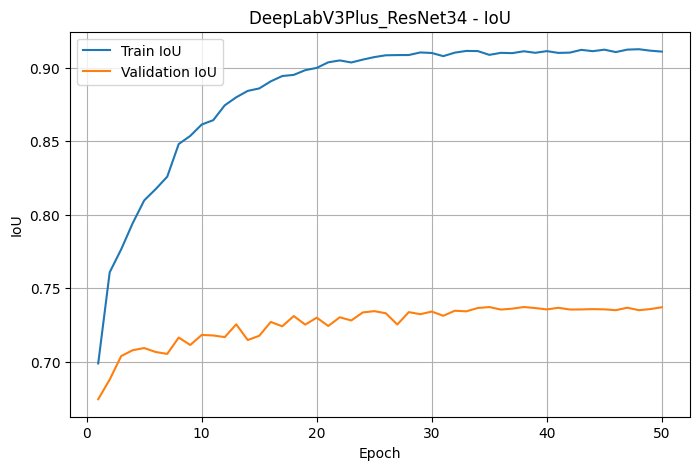

In [117]:
# Cell 57 — Training and validation IoU

for model_name, history in all_histories.items():

    df = pd.DataFrame(history)

    plt.figure(figsize=(8, 5))

    plt.plot(df["epoch"], df["train_iou"], label="Train IoU")
    plt.plot(df["epoch"], df["val_iou"], label="Validation IoU")

    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.title(f"{model_name} - IoU")
    plt.legend()
    plt.grid(True)
    plt.show()

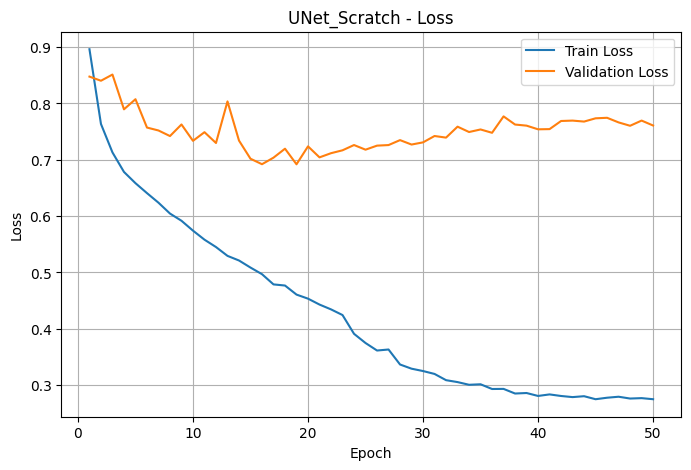

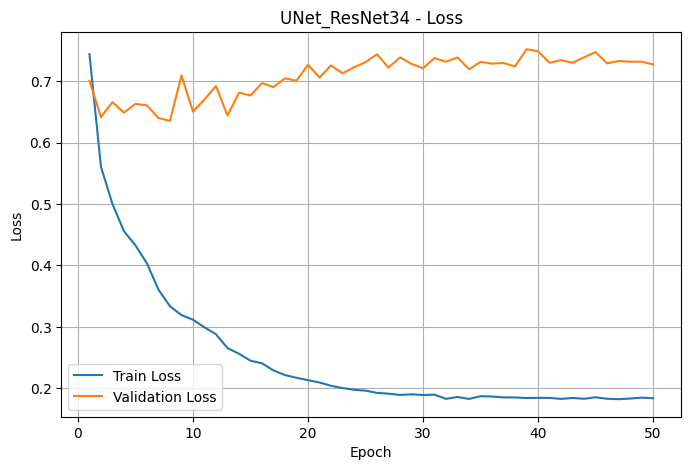

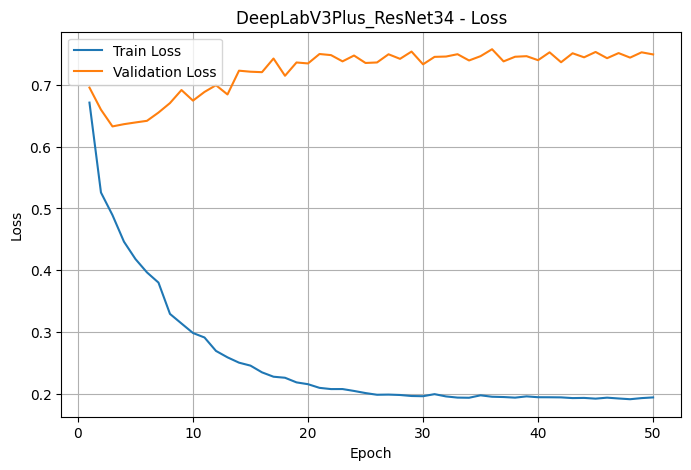

In [118]:
# Cell 58 — Training and validation loss

for model_name, history in all_histories.items():

    df = pd.DataFrame(history)

    plt.figure(figsize=(8, 5))

    plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
    plt.plot(df["epoch"], df["val_loss"], label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

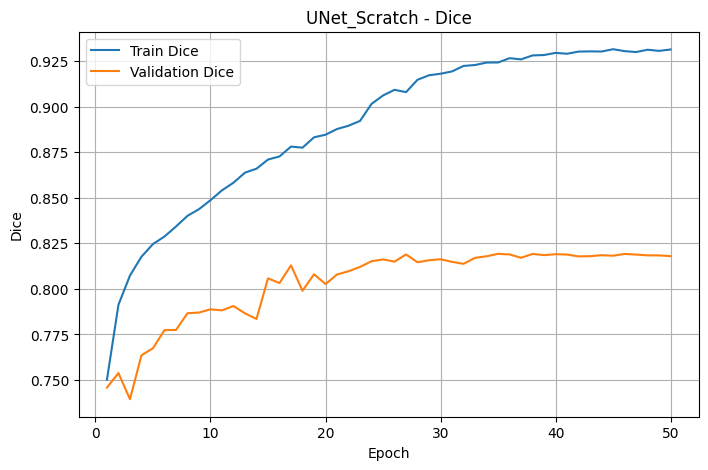

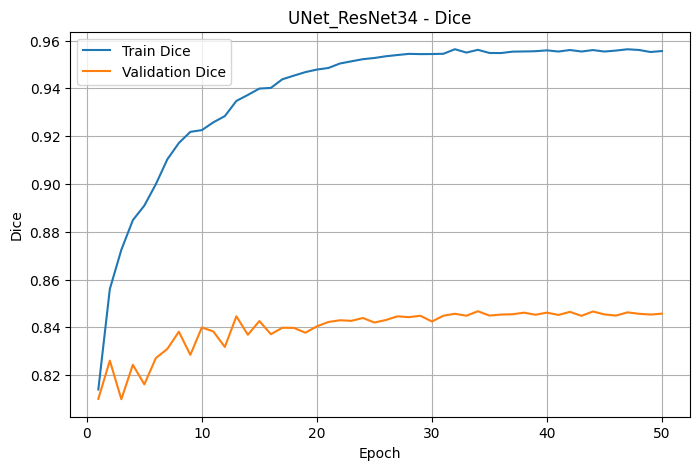

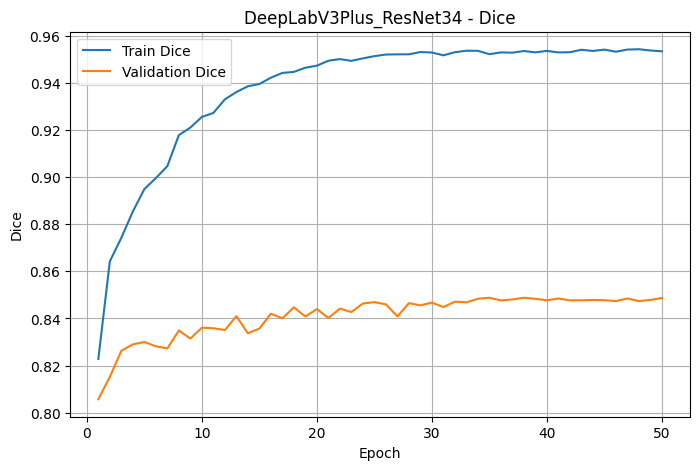

In [119]:
# Cell 59 — Training and validation Dice

for model_name, history in all_histories.items():

    df = pd.DataFrame(history)

    plt.figure(figsize=(8, 5))

    plt.plot(df["epoch"], df["train_dice"], label="Train Dice")
    plt.plot(df["epoch"], df["val_dice"], label="Validation Dice")

    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.title(f"{model_name} - Dice")
    plt.legend()
    plt.grid(True)
    plt.show()

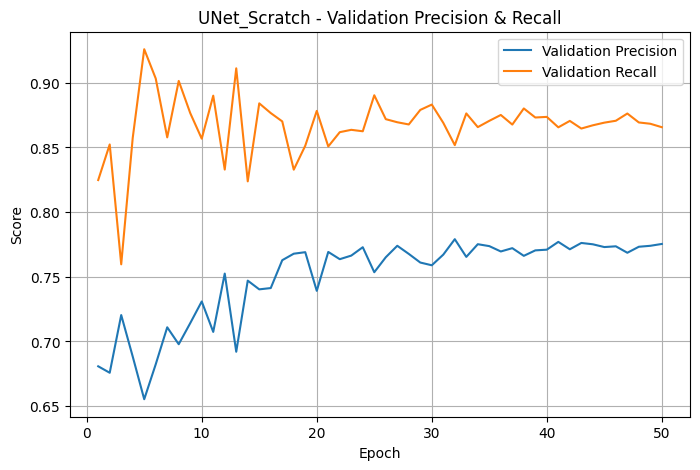

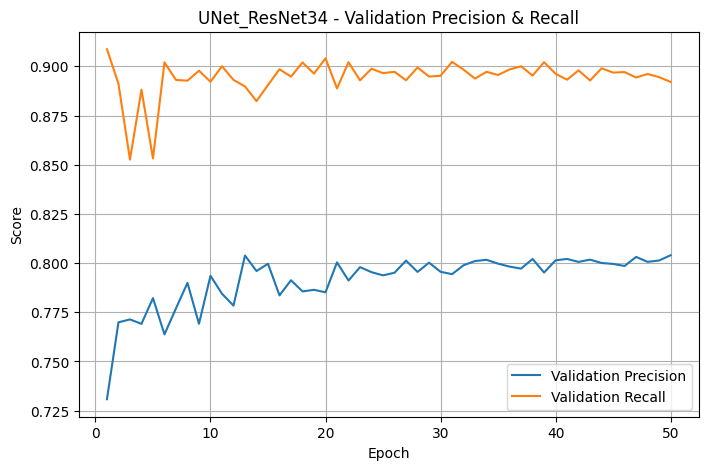

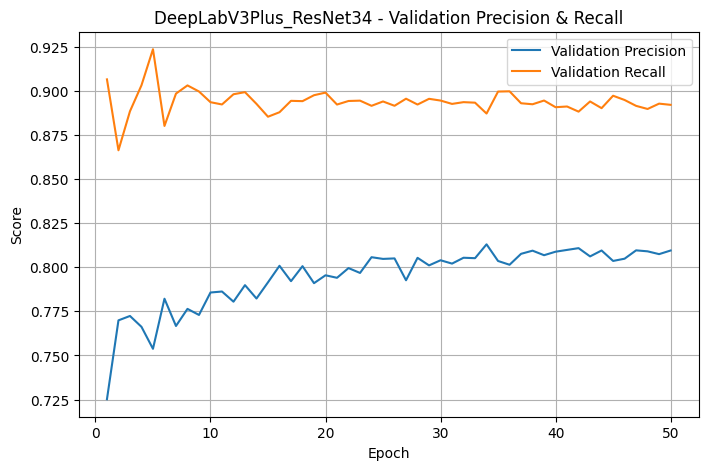

In [120]:
# Cell 60 — Validation Precision and Recall

for model_name, history in all_histories.items():

    df = pd.DataFrame(history)

    plt.figure(figsize=(8, 5))

    plt.plot(df["epoch"], df["val_precision"], label="Validation Precision")
    plt.plot(df["epoch"], df["val_recall"], label="Validation Recall")

    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(f"{model_name} - Validation Precision & Recall")
    plt.legend()
    plt.grid(True)
    plt.show()

In [121]:
# Cell 61 — Best epoch information

best_epoch_summary = []

for model_name, history in all_histories.items():

    df = pd.DataFrame(history)

    best_loss_row = df.loc[df["val_loss"].idxmin()]
    best_iou_row = df.loc[df["val_iou"].idxmax()]

    best_epoch_summary.append({
        "Model": model_name,
        "Best Epoch by Val Loss": int(best_loss_row["epoch"]),
        "Best Val Loss": best_loss_row["val_loss"],
        "Best Epoch by Val IoU": int(best_iou_row["epoch"]),
        "Best Val IoU": best_iou_row["val_iou"],
        "Best Val Dice": df["val_dice"].max()
    })

best_epoch_df = pd.DataFrame(best_epoch_summary)

display(best_epoch_df)

,Model,Best Epoch by Val Loss,Best Val Loss,Best Epoch by Val IoU,Best Val IoU,Best Val Dice
0,UNet_Scratch,19,0.691985,35,0.693836,0.819248
1,UNet_ResNet34,8,0.635453,34,0.734219,0.846743
2,DeepLabV3Plus_ResNet34,3,0.632691,38,0.737325,0.848805


In [122]:
# Cell 62 — Save best epoch summary

best_epoch_df.to_csv(
    "/kaggle/working/best_epoch_summary.csv",
    index=False
)

print("Best epoch summary saved.")

Best epoch summary saved.


In [123]:
# Cell 63 — Check saved model checkpoints

from pathlib import Path

for model_name in models.keys():

    best_path = Path(f"/kaggle/working/{model_name}_best.pth")
    final_path = Path(f"/kaggle/working/{model_name}_final.pth")

    print(f"\n{model_name}")
    print("Best checkpoint :", best_path.exists())
    print("Final checkpoint:", final_path.exists())


UNet_Scratch
Best checkpoint : True
Final checkpoint: False

UNet_ResNet34
Best checkpoint : True
Final checkpoint: False

DeepLabV3Plus_ResNet34
Best checkpoint : True
Final checkpoint: False


In [124]:
# Cell 64 — Check output files

important_files = [
    "/kaggle/working/dust_segmenter.onnx",
    "/kaggle/working/final_model_comparison.csv",
    "/kaggle/working/complete_segmentation_results.csv",
    "/kaggle/working/final_epoch_test_results.csv",
    "/kaggle/working/best_epoch_summary.csv"
]

for file_path in important_files:
    exists = os.path.exists(file_path)
    print("✓" if exists else "✗", file_path)

✓ /kaggle/working/dust_segmenter.onnx
✓ /kaggle/working/final_model_comparison.csv
✓ /kaggle/working/complete_segmentation_results.csv
✓ /kaggle/working/final_epoch_test_results.csv
✓ /kaggle/working/best_epoch_summary.csv


In [125]:
# Cell 65 — Create final project output folder

FINAL_DIR = Path("/kaggle/working/final_project_outputs")

FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Created:", FINAL_DIR)

Created: /kaggle/working/final_project_outputs


In [126]:
# Cell 66 — Copy important final outputs

import shutil

files_to_copy = [
    "dust_segmenter.onnx",
    "final_model_comparison.csv",
    "complete_segmentation_results.csv",
    "final_epoch_test_results.csv",
    "best_epoch_summary.csv"
]

for filename in files_to_copy:

    source = Path("/kaggle/working") / filename
    destination = FINAL_DIR / filename

    if source.exists():
        shutil.copy2(source, destination)
        print("Copied:", filename)
    else:
        print("Missing:", filename)

Copied: dust_segmenter.onnx
Copied: final_model_comparison.csv
Copied: complete_segmentation_results.csv
Copied: final_epoch_test_results.csv
Copied: best_epoch_summary.csv


In [127]:
# Cell 67 — Save individual training histories

HISTORY_DIR = FINAL_DIR / "training_histories"
HISTORY_DIR.mkdir(parents=True, exist_ok=True)

for model_name, history in all_histories.items():

    safe_name = model_name.replace(" ", "_")

    path = HISTORY_DIR / f"{safe_name}_history.csv"

    pd.DataFrame(history).to_csv(
        path,
        index=False
    )

    print("Saved:", path)

Saved: /kaggle/working/final_project_outputs/training_histories/UNet_Scratch_history.csv
Saved: /kaggle/working/final_project_outputs/training_histories/UNet_ResNet34_history.csv
Saved: /kaggle/working/final_project_outputs/training_histories/DeepLabV3Plus_ResNet34_history.csv


In [130]:
# Cell 68 — Save experiment configuration

experiment_config = {
    "dataset": "Roboflow Solar Dust",
    "dataset_version": 1,
    "task": "Semantic Segmentation",
    "image_size": "256x256",
    "epochs": 50,
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "learning_rate": 1e-4,
    "scheduler": "ReduceLROnPlateau",
    "loss": "BCE + Dice",
    "models": [
        "UNet_Scratch",
        "UNet_ResNet34",
        "DeepLabV3Plus_ResNet34"
    ],
    "best_model": "DeepLabV3Plus_ResNet34"
}

with open(FINAL_DIR / "experiment_config.json", "w") as f:
    json.dump(experiment_config, f, indent=4)

print("Experiment configuration saved.")

Experiment configuration saved.


In [131]:
# Cell 69 — List all final outputs

print("=" * 60)
print("FINAL PROJECT OUTPUTS")
print("=" * 60)

for file in FINAL_DIR.rglob("*"):
    if file.is_file():
        size_mb = file.stat().st_size / (1024 * 1024)
        print(
            f"{file.relative_to(FINAL_DIR)} "
            f"({size_mb:.2f} MB)"
        )

FINAL PROJECT OUTPUTS
final_model_comparison.csv (0.00 MB)
dust_segmenter.onnx (0.26 MB)
final_epoch_test_results.csv (0.00 MB)
complete_segmentation_results.csv (0.00 MB)
best_epoch_summary.csv (0.00 MB)
experiment_config.json (0.00 MB)
training_histories/DeepLabV3Plus_ResNet34_history.csv (0.02 MB)
training_histories/UNet_Scratch_history.csv (0.02 MB)
training_histories/UNet_ResNet34_history.csv (0.02 MB)


In [132]:
# Cell 70 — Final project summary

print("=" * 60)
print("SOLAR PANEL DUST SEGMENTATION")
print("FINAL SUMMARY")
print("=" * 60)

print("\nDataset")
print("Train :", split_counts["train"])
print("Valid :", split_counts["valid"])
print("Test  :", split_counts["test"])
print("Total :", total_images)

print("\nPixel Distribution")
print("Background : 59.20%")
print("Dust       : 40.80%")

print("\nTraining Configuration")
print("Epochs     :", EPOCHS)
print("Batch size :", BATCH_SIZE)
print("Optimizer  : Adam")
print("LR         : 1e-4")
print("Loss       : BCE + Dice")
print("Scheduler  : ReduceLROnPlateau")

print("\nBest Model")
print("DeepLabV3Plus_ResNet34")

print("\nFinal Test Comparison")
display(comparison)

print("\nONNX Model")
print("Path   :", onnx_path)
print("Exists :", os.path.exists(onnx_path))

print("\nPipeline completed successfully.")

SOLAR PANEL DUST SEGMENTATION
FINAL SUMMARY

Dataset
Train : 5961
Valid : 524
Test  : 270
Total : 6755

Pixel Distribution
Background : 59.20%
Dust       : 40.80%

Training Configuration
Epochs     : 50
Batch size : 16
Optimizer  : Adam
LR         : 1e-4
Loss       : BCE + Dice
Scheduler  : ReduceLROnPlateau

Best Model
DeepLabV3Plus_ResNet34

Final Test Comparison


,Model,Test Loss,Test IoU,Test Dice,Test Precision,Test Recall,model
0,"([[tensor([[[0.5686, 0.5725, 0.5765, ..., 0.2...",0.579944,0.735649,0.845814,0.821875,0.877501,UNet_ResNet34
1,"([[tensor([[[0.5686, 0.5725, 0.5765, ..., 0.2...",0.588410,0.696955,0.818536,0.789331,0.858587,DeepLabV3Plus_ResNet34
2,"([[tensor([[[0.5686, 0.5725, 0.5765, ..., 0.2...",0.644043,0.676643,0.805514,0.803852,0.815055,UNet_Scratch



ONNX Model
Path   : /kaggle/working/dust_segmenter.onnx
Exists : True

Pipeline completed successfully.


In [133]:
import shutil

zip_path = shutil.make_archive(
    "/kaggle/working/solar_dust_final_outputs",
    "zip",
    "/kaggle/working/final_project_outputs"
)

print(zip_path)

/kaggle/working/solar_dust_final_outputs.zip


In [136]:
# Find history-related variables safely

history_vars = [
    (name, value)
    for name, value in list(globals().items())
    if "history" in name.lower()
]

for name, value in history_vars:
    print(name, type(value))

history <class 'dict'>
history_df <class 'pandas.core.frame.DataFrame'>
HISTORY_DIR <class 'pathlib._local.PosixPath'>


In [138]:
print("history type:", type(history))

if isinstance(history, dict):
    print("\nHistory keys:")
    for key in history.keys():
        print(key)

print("\nHistory DataFrame:")
print(history_df.columns.tolist())
print("\nShape:", history_df.shape)

display(history_df.head())

history type: <class 'dict'>

History keys:
epoch
train_loss
train_accuracy
train_precision
train_recall
train_f1
train_dice
train_dice_loss
train_iou
val_loss
val_accuracy
val_precision
val_recall
val_f1
val_dice
val_dice_loss
val_iou
learning_rate
epoch_time
best_epoch
best_val_loss
total_wall_time

History DataFrame:
['epoch', 'train_loss', 'train_accuracy', 'train_precision', 'train_recall', 'train_f1', 'train_dice', 'train_dice_loss', 'train_iou', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_f1', 'val_dice', 'val_dice_loss', 'val_iou', 'learning_rate', 'epoch_time', 'best_epoch', 'best_val_loss', 'total_wall_time']

Shape: (50, 22)


,epoch,train_loss,train_accuracy,train_precision,train_recall,train_f1,train_dice,train_dice_loss,train_iou,val_loss,...,val_recall,val_f1,val_dice,val_dice_loss,val_iou,learning_rate,epoch_time,best_epoch,best_val_loss,total_wall_time
0,1,0.671186,0.833164,0.778486,0.872534,0.822831,0.822831,0.177169,0.698992,0.695489,...,0.906380,0.805742,0.805742,0.194258,0.674681,0.0001,95.644362,3,0.632691,4740.956676
1,2,0.525858,0.873931,0.827926,0.903893,0.864243,0.864243,0.135757,0.760941,0.659759,...,0.866215,0.815218,0.815218,0.184782,0.688074,0.0001,94.318055,3,0.632691,4740.956676
2,3,0.489316,0.883697,0.840942,0.910280,0.874238,0.874238,0.125762,0.776575,0.632691,...,0.888309,0.826294,0.826294,0.173706,0.704005,0.0001,93.711298,3,0.632691,4740.956676
3,4,0.446322,0.895067,0.859293,0.913091,0.885375,0.885375,0.114625,0.794326,0.636310,...,0.903025,0.829021,0.829021,0.170979,0.707973,0.0001,94.263048,3,0.632691,4740.956676
4,5,0.418221,0.903878,0.870003,0.921256,0.894896,0.894896,0.105104,0.809785,0.639097,...,0.923461,0.830036,0.830036,0.169964,0.709454,0.0001,94.995060,3,0.632691,4740.956676


In [140]:
# ============================================================
# FINAL MODEL COMPARISON
# TRAIN + VALIDATION + TEST
# ============================================================

import pandas as pd
import os
from pathlib import Path

# ------------------------------------------------------------
# 1. Find saved training history CSV files
# ------------------------------------------------------------

print("Training history files:")

history_files = list(Path(HISTORY_DIR).glob("*.csv"))

for f in history_files:
    print(f)

Training history files:
/kaggle/working/final_project_outputs/training_histories/DeepLabV3Plus_ResNet34_history.csv
/kaggle/working/final_project_outputs/training_histories/UNet_Scratch_history.csv
/kaggle/working/final_project_outputs/training_histories/UNet_ResNet34_history.csv


In [4]:
# ============================================================
# FINAL MODEL COMPARISON - AUTO FIND HISTORY FILES
# ============================================================

import pandas as pd
from pathlib import Path

# Automatically find all history CSV files
history_dir = Path("/kaggle/working/final_project_outputs/training_histories")

history_files = list(history_dir.glob("*_history.csv"))

print("Found history files:")
for f in history_files:
    print(" -", f)

# ------------------------------------------------------------
# Load histories
# ------------------------------------------------------------

comparison_rows = []

for history_file in history_files:

    # Model name from filename
    model_name = history_file.stem.replace("_history", "")

    print(f"\nProcessing: {model_name}")

    df = pd.read_csv(history_file)

    # Best epoch = minimum validation loss
    best_idx = df["val_loss"].idxmin()
    best = df.loc[best_idx]

    # Wall time
    wall_time = df["total_wall_time"].iloc[-1]

    # --------------------------------------------------------
    # Find test result
    # --------------------------------------------------------

    test_rows = final_test_results_df[
        final_test_results_df["model"] == model_name
    ]

    if len(test_rows) > 0:

        test = test_rows.iloc[0]

        # Print available test columns once
        test_loss = test.get("loss", test.get("test_loss", None))
        test_accuracy = test.get("accuracy", test.get("test_accuracy", None))
        test_precision = test.get("precision", test.get("test_precision", None))
        test_recall = test.get("recall", test.get("test_recall", None))
        test_f1 = test.get("f1", test.get("test_f1", None))
        test_dice = test.get("dice", test.get("test_dice", None))
        test_iou = test.get("iou", test.get("test_iou", None))
        test_auc = test.get("roc_auc", test.get("test_roc_auc", None))

    else:
        test_loss = None
        test_accuracy = None
        test_precision = None
        test_recall = None
        test_f1 = None
        test_dice = None
        test_iou = None
        test_auc = None

    # --------------------------------------------------------
    # Add row
    # --------------------------------------------------------

    comparison_rows.append({

        "Model": model_name,

        "Best Epoch": int(best["epoch"]),
        "Wall Time (min)": wall_time / 60,
        "Learning Rate": best["learning_rate"],

        # TRAIN
        "Train Loss": best["train_loss"],
        "Train Accuracy": best["train_accuracy"],
        "Train Precision": best["train_precision"],
        "Train Recall": best["train_recall"],
        "Train F1": best["train_f1"],
        "Train Dice": best["train_dice"],
        "Train Dice Loss": best["train_dice_loss"],
        "Train IoU": best["train_iou"],

        # VALIDATION
        "Val Loss": best["val_loss"],
        "Val Accuracy": best["val_accuracy"],
        "Val Precision": best["val_precision"],
        "Val Recall": best["val_recall"],
        "Val F1": best["val_f1"],
        "Val Dice": best["val_dice"],
        "Val Dice Loss": best["val_dice_loss"],
        "Val IoU": best["val_iou"],

        # TEST
        "Test Loss": test_loss,
        "Test Accuracy": test_accuracy,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1": test_f1,
        "Test Dice": test_dice,
        "Test IoU": test_iou,
        "Test ROC-AUC": test_auc
    })


# ============================================================
# FINAL TABLE
# ============================================================

final_model_comparison = pd.DataFrame(comparison_rows)

print("\n")
print("=" * 120)
print("FINAL MODEL EVALUATION COMPARISON")
print("=" * 120)

display(final_model_comparison.round(4))


# ============================================================
# SAVE
# ============================================================

output_path = "/kaggle/working/final_model_evaluation_comparison.csv"

final_model_comparison.to_csv(
    output_path,
    index=False
)

print("\nSaved successfully:")
print(output_path)

Found history files:


FINAL MODEL EVALUATION COMPARISON


""



Saved successfully:
/kaggle/working/final_model_evaluation_comparison.csv


In [9]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.7 MB/s eta 0:00:0000:01


In [10]:
import segmentation_models_pytorch as smp

print("SMP version:", smp.__version__)
print("Segmentation Models PyTorch imported successfully!")

SMP version: 0.5.0
Segmentation Models PyTorch imported successfully!


In [11]:
!pip install -q segmentation-models-pytorch

In [14]:
import segmentation_models_pytorch as smp


UNet_Scratch
Checkpoint:
/kaggle/working/UNet_Scratch_best.pth
CHECKPOINT NOT FOUND

UNet_ResNet34
Checkpoint:
/kaggle/working/UNet_ResNet34_best.pth
CHECKPOINT NOT FOUND

DeepLabV3Plus_ResNet34
Checkpoint:
/kaggle/working/DeepLabV3Plus_ResNet34_best.pth
CHECKPOINT NOT FOUND


FINAL TEST SET COMPARISON


""



Saved:
/kaggle/working/final_evaluation/final_test_evaluation_comparison.csv


/tmp/ipykernel_49/4149342194.py:550: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


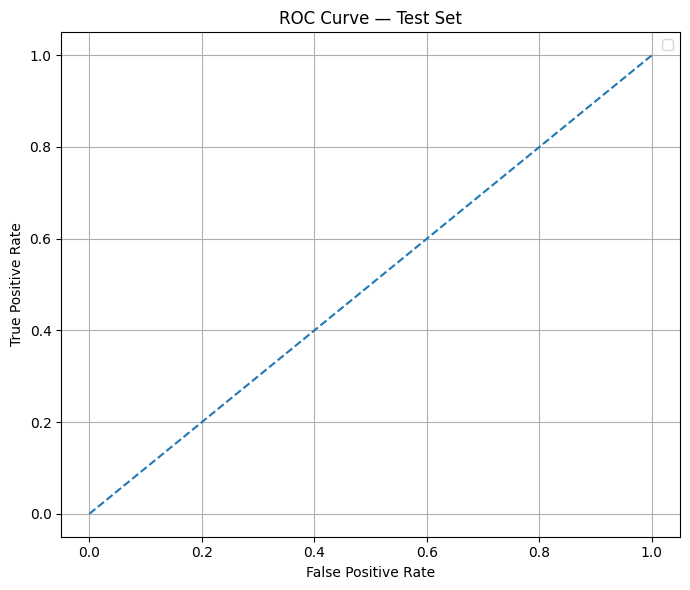

/tmp/ipykernel_49/4149342194.py:596: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


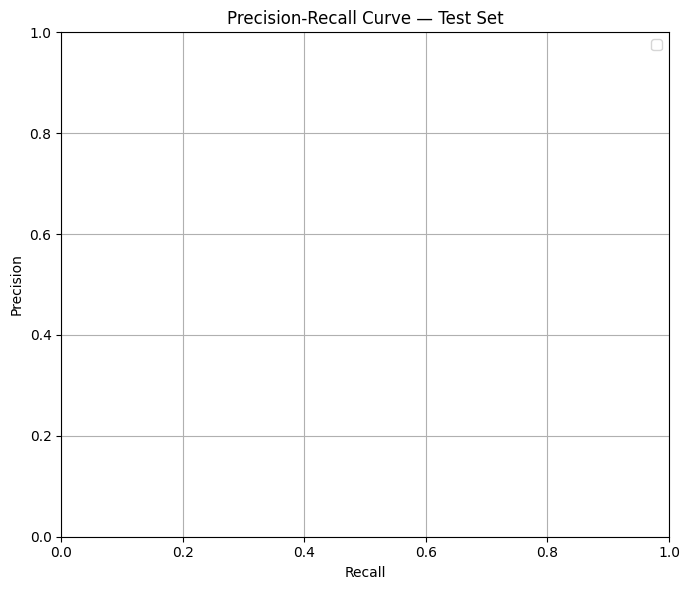

/tmp/ipykernel_49/4149342194.py:640: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


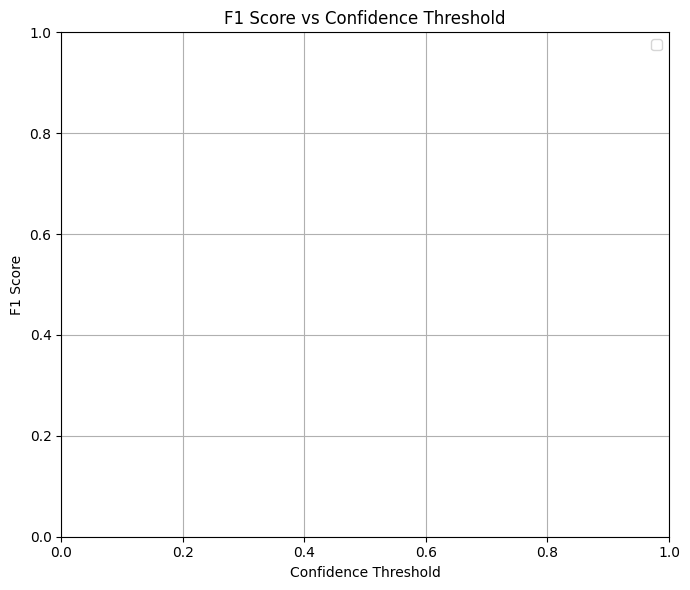


ALL TEST EVALUATIONS COMPLETED
Output folder:
/kaggle/working/final_evaluation


In [15]:
# ============================================================
# COMPLETE TEST EVALUATION - ALL 3 MODELS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import segmentation_models_pytorch as smp

OUTPUT_DIR = "/kaggle/working/final_evaluation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_NAMES = [
    "UNet_Scratch",
    "UNet_ResNet34",
    "DeepLabV3Plus_ResNet34"
]

# ------------------------------------------------------------
# CREATE MODEL
# ------------------------------------------------------------

def create_model(model_name):

    if model_name == "UNet_Scratch":

        model = smp.Unet(
            encoder_name="resnet34",
            encoder_weights=None,
            in_channels=3,
            classes=1
        )

    elif model_name == "UNet_ResNet34":

        model = smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=3,
            classes=1
        )

    elif model_name == "DeepLabV3Plus_ResNet34":

        model = smp.DeepLabV3Plus(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=3,
            classes=1
        )

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return model.to(device)


# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

def calculate_metrics(TP, TN, FP, FN):

    eps = 1e-7

    accuracy = (TP + TN) / (
        TP + TN + FP + FN + eps
    )

    precision = TP / (
        TP + FP + eps
    )

    recall = TP / (
        TP + FN + eps
    )

    f1 = (
        2 * precision * recall
        / (precision + recall + eps)
    )

    dice = (
        2 * TP
        / (2 * TP + FP + FN + eps)
    )

    dice_loss = 1 - dice

    iou = (
        TP
        / (TP + FP + FN + eps)
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Dice": dice,
        "Dice Loss": dice_loss,
        "IoU": iou
    }


# ============================================================
# EVALUATE ALL 3 MODELS
# ============================================================

all_test_results = {}

for model_name in MODEL_NAMES:

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    checkpoint_path = (
        f"/kaggle/working/{model_name}_best.pth"
    )

    print("Checkpoint:")
    print(checkpoint_path)

    if not os.path.exists(checkpoint_path):
        print("CHECKPOINT NOT FOUND")
        continue

    # Create fresh model
    model = create_model(model_name)

    # Load best checkpoint
    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=device
        )
    )

    model.eval()

    TP = 0
    TN = 0
    FP = 0
    FN = 0

    total_loss = 0.0
    total_batches = 0

    all_probs = []
    all_targets = []

    with torch.no_grad():

        for images, masks in test_loader:

            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)

            loss = criterion(
                logits,
                masks
            )

            total_loss += loss.item()
            total_batches += 1

            probs = torch.sigmoid(logits)

            preds = (
                probs >= 0.5
            ).float()

            TP += (
                (preds == 1) &
                (masks == 1)
            ).sum().item()

            TN += (
                (preds == 0) &
                (masks == 0)
            ).sum().item()

            FP += (
                (preds == 1) &
                (masks == 0)
            ).sum().item()

            FN += (
                (preds == 0) &
                (masks == 1)
            ).sum().item()

            all_probs.append(
                probs.cpu().numpy().ravel()
            )

            all_targets.append(
                masks.cpu().numpy().ravel()
            )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    metrics = calculate_metrics(
        TP,
        TN,
        FP,
        FN
    )

    test_loss = (
        total_loss /
        total_batches
    )

    y_prob = np.concatenate(
        all_probs
    )

    y_true = np.concatenate(
        all_targets
    )

    # --------------------------------------------------------
    # ROC-AUC
    # --------------------------------------------------------

    from sklearn.metrics import (
        roc_curve,
        auc,
        precision_recall_curve,
        average_precision_score
    )

    fpr, tpr, _ = roc_curve(
        y_true,
        y_prob
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    # --------------------------------------------------------
    # Precision-Recall
    # --------------------------------------------------------

    pr_precision, pr_recall, _ = (
        precision_recall_curve(
            y_true,
            y_prob
        )
    )

    average_precision = (
        average_precision_score(
            y_true,
            y_prob
        )
    )

    # --------------------------------------------------------
    # F1 vs Confidence
    # --------------------------------------------------------

    thresholds = np.arange(
        0.1,
        1.0,
        0.05
    )

    f1_scores = []

    for threshold in thresholds:

        threshold_preds = (
            y_prob >= threshold
        ).astype(np.uint8)

        tp = np.sum(
            (threshold_preds == 1) &
            (y_true == 1)
        )

        fp = np.sum(
            (threshold_preds == 1) &
            (y_true == 0)
        )

        fn = np.sum(
            (threshold_preds == 0) &
            (y_true == 1)
        )

        precision = (
            tp / (tp + fp + 1e-7)
        )

        recall = (
            tp / (tp + fn + 1e-7)
        )

        f1 = (
            2 * precision * recall
            / (precision + recall + 1e-7)
        )

        f1_scores.append(f1)

    best_index = np.argmax(
        f1_scores
    )

    best_confidence = thresholds[
        best_index
    ]

    best_f1 = f1_scores[
        best_index
    ]

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    all_test_results[model_name] = {

        "Test Loss": test_loss,

        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1": metrics["F1"],
        "Dice": metrics["Dice"],
        "Dice Loss": metrics["Dice Loss"],
        "IoU": metrics["IoU"],

        "ROC-AUC": roc_auc,
        "Average Precision": average_precision,

        "Best Confidence": best_confidence,
        "Best F1": best_f1,

        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,

        "FPR": fpr,
        "TPR": tpr,

        "PR Precision": pr_precision,
        "PR Recall": pr_recall,

        "Confidence Thresholds": thresholds,
        "F1 Scores": f1_scores
    }

    print(f"Test Loss     : {test_loss:.4f}")
    print(f"Accuracy      : {metrics['Accuracy']:.4f}")
    print(f"Precision     : {metrics['Precision']:.4f}")
    print(f"Recall        : {metrics['Recall']:.4f}")
    print(f"F1            : {metrics['F1']:.4f}")
    print(f"Dice          : {metrics['Dice']:.4f}")
    print(f"Dice Loss     : {metrics['Dice Loss']:.4f}")
    print(f"IoU           : {metrics['IoU']:.4f}")
    print(f"ROC-AUC       : {roc_auc:.4f}")
    print(f"Average Prec. : {average_precision:.4f}")
    print(f"Best F1       : {best_f1:.4f}")
    print(f"Best Threshold: {best_confidence:.2f}")


# ============================================================
# FINAL TEST COMPARISON TABLE
# ============================================================

rows = []

for model_name in MODEL_NAMES:

    if model_name not in all_test_results:
        continue

    r = all_test_results[model_name]

    rows.append({

        "Model": model_name,

        "Test Loss": r["Test Loss"],
        "Accuracy": r["Accuracy"],
        "Precision": r["Precision"],
        "Recall": r["Recall"],
        "F1": r["F1"],
        "Dice": r["Dice"],
        "Dice Loss": r["Dice Loss"],
        "IoU": r["IoU"],

        "ROC-AUC": r["ROC-AUC"],
        "Average Precision": r["Average Precision"],

        "Best Confidence": r["Best Confidence"],
        "Best F1": r["Best F1"],

        "TP": r["TP"],
        "TN": r["TN"],
        "FP": r["FP"],
        "FN": r["FN"]
    })


test_comparison_df = pd.DataFrame(rows)

print("\n")
print("=" * 120)
print("FINAL TEST SET COMPARISON")
print("=" * 120)

display(
    test_comparison_df.round(4)
)


# ============================================================
# SAVE CSV
# ============================================================

test_csv = os.path.join(
    OUTPUT_DIR,
    "final_test_evaluation_comparison.csv"
)

test_comparison_df.to_csv(
    test_csv,
    index=False
)

print("\nSaved:")
print(test_csv)


# ============================================================
# CONFUSION MATRICES
# ============================================================

for model_name in MODEL_NAMES:

    if model_name not in all_test_results:
        continue

    r = all_test_results[model_name]

    cm = np.array([
        [r["TN"], r["FP"]],
        [r["FN"], r["TP"]]
    ])

    plt.figure(figsize=(5, 4))

    plt.imshow(cm)

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks(
        [0, 1],
        ["Background", "Dust"]
    )

    plt.yticks(
        [0, 1],
        ["Background", "Dust"]
    )

    for i in range(2):
        for j in range(2):

            plt.text(
                j,
                i,
                f"{cm[i,j]:,}",
                ha="center",
                va="center"
            )

    plt.colorbar()

    plt.tight_layout()

    path = os.path.join(
        OUTPUT_DIR,
        f"{model_name}_confusion_matrix.png"
    )

    plt.savefig(
        path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# ROC CURVE
# ============================================================

plt.figure(figsize=(7, 6))

for model_name in MODEL_NAMES:

    if model_name not in all_test_results:
        continue

    r = all_test_results[model_name]

    plt.plot(
        r["FPR"],
        r["TPR"],
        label=(
            f"{model_name} "
            f"(AUC={r['ROC-AUC']:.3f})"
        )
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve — Test Set"
)

plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "ROC_curve_all_models.png"
    ),
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

plt.figure(figsize=(7, 6))

for model_name in MODEL_NAMES:

    if model_name not in all_test_results:
        continue

    r = all_test_results[model_name]

    plt.plot(
        r["PR Recall"],
        r["PR Precision"],
        label=(
            f"{model_name} "
            f"(AP={r['Average Precision']:.3f})"
        )
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve — Test Set"
)

plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "Precision_Recall_curve_all_models.png"
    ),
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# F1 vs CONFIDENCE
# ============================================================

plt.figure(figsize=(7, 6))

for model_name in MODEL_NAMES:

    if model_name not in all_test_results:
        continue

    r = all_test_results[model_name]

    plt.plot(
        r["Confidence Thresholds"],
        r["F1 Scores"],
        marker="o",
        label=model_name
    )

plt.xlabel("Confidence Threshold")
plt.ylabel("F1 Score")

plt.title(
    "F1 Score vs Confidence Threshold"
)

plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "F1_vs_confidence_all_models.png"
    ),
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print("\n" + "=" * 80)
print("ALL TEST EVALUATIONS COMPLETED")
print("=" * 80)

print("Output folder:")
print(OUTPUT_DIR)

In [22]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        if file.endswith(".pth"):
            print(os.path.join(root, file))

In [21]:
!find /kaggle/working -name "*.pth"